In [1]:
import anndata as ad
import pandas as pd
import scanpy as sc
from pathlib import Path
import os
import sklearn
import scipy
import numpy as np
import sceleto2 as scl
import pickle
import glob
import os
import scrublet as scr
import matplotlib.pyplot as plt


sc.settings.verbosity = 3
sc.logging.print_header()
sc.settings.set_figure_params(dpi=100, dpi_save=300, figsize=(5,5))
sc.settings.figdir = "./figures"
sc.settings.autosave = False
random_seed = 0

from datetime import date
TODAY = date.today()
print(TODAY)

/home/lsj1022/anaconda3/envs/scenv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


2026-09-13


In [2]:
dataset = 'liu'

# 1. QC

In [3]:
#adata = sc.read_h5ad("/home/neuro_demo_research/repo/epilepsy_microglia_repo/notebooks/epilepsy_microglia/data/processed/galvao/galvao.h5ad")
adata = sc.read_h5ad(f"/data/SJLEE/Epilepsy_Microglia/notebooks/epilepsy_microglia/data/processed/{dataset}/{dataset}.h5ad")
adata

AnnData object with n_obs × n_vars = 20153934 × 33694
    obs: 'GSM', 'study_id', 'dataset_id', 'species', 'disease_status', 'fcd_subtype', 'driver_mutation_status', 'driver_gene', 'driver_variant', 'mutation_scope', 'brain_region_raw', 'brain_region', 'epilepsy_duration_years', 'sample_source', 'tissue_state', 'cell_or_nucleus', 'platform', 'chemistry', 'raw_counts_available', 'cell_metadata_available', 'genetic_metadata_available', 'main_analysis_eligible', 'exclusion_reason', 'processed_file_format', 'geo_downloadable', 'source_url', 'sample_id', 'donor_id', 'donor_id_global', 'diagnosis_raw', 'diagnosis_harmonized', 'fcd_class', 'mtoropathy_status', 'lesion_position', 'control_type', 'age_years', 'sex', 'n_cells_raw', 'n_cells_qc', 'n_microglia'
    var: 'ensembl_id', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mapping_status', 'gene_symbols'
    uns: 'hvg', 'log1p'
    layers: 'counts'

## Debugging dataset structure

### take 1. check data structure

In [4]:
print(adata.shape)

print(adata.obs.head())
print(adata.obs.columns)

print(adata.obs.index[:20])
print("obs unique:", adata.obs_names.is_unique)

if "sample" in adata.obs:
    print(adata.obs["sample"].value_counts())

if "donor" in adata.obs:
    print(adata.obs["donor"].value_counts())

(20153934, 33694)
                                      GSM study_id dataset_id species  \
AAACCCAAGAAACACT-1-GSM8244661  GSM8244661  Liu2024  GSE266305   human   
AAACCCAAGAAACCAT-1-GSM8244661  GSM8244661  Liu2024  GSE266305   human   
AAACCCAAGAAACTAC-1-GSM8244661  GSM8244661  Liu2024  GSE266305   human   
AAACCCAAGAAACTCA-1-GSM8244661  GSM8244661  Liu2024  GSE266305   human   
AAACCCAAGAAACTGC-1-GSM8244661  GSM8244661  Liu2024  GSE266305   human   

                              disease_status fcd_subtype  \
AAACCCAAGAAACACT-1-GSM8244661       epilepsy          NA   
AAACCCAAGAAACCAT-1-GSM8244661       epilepsy          NA   
AAACCCAAGAAACTAC-1-GSM8244661       epilepsy          NA   
AAACCCAAGAAACTCA-1-GSM8244661       epilepsy          NA   
AAACCCAAGAAACTGC-1-GSM8244661       epilepsy          NA   

                              driver_mutation_status driver_gene  \
AAACCCAAGAAACACT-1-GSM8244661             not_tested         NaN   
AAACCCAAGAAACCAT-1-GSM8244661             not_

In [ ]:
adata.obs["GSM"].value_counts() if "GSM" in adata.obs else adata.obs["sample_id"].value_counts()

GSM
GSM8244661    3098997
GSM8244662    3088885
GSM8244664    3000130
GSM8244666    2959441
GSM8244663    2774811
GSM8244667    2749412
GSM8244665    2482258
Name: count, dtype: int64

In [11]:
import numpy as np

for gsm in adata.obs["GSM"].unique():
    x = adata[adata.obs["GSM"] == gsm].X
    counts = np.asarray(x.sum(axis=1)).ravel()

    print(
        gsm,
        "total =", len(counts),
        ">=100 =", np.sum(counts >= 100),
        ">=500 =", np.sum(counts >= 500),
        ">=1000 =", np.sum(counts >= 1000),
        ">=1500 =", np.sum(counts >= 1500),
    )

GSM8244661 total = 3098997 >=100 = 84248 >=500 = 83267 >=1000 = 82748 >=1500 = 54557
GSM8244662 total = 3088885 >=100 = 85434 >=500 = 84199 >=1000 = 83583 >=1500 = 53303
GSM8244663 total = 2774811 >=100 = 86506 >=500 = 85768 >=1000 = 85225 >=1500 = 56345
GSM8244664 total = 3000130 >=100 = 84171 >=500 = 83036 >=1000 = 82396 >=1500 = 45451
GSM8244665 total = 2482258 >=100 = 86085 >=500 = 82958 >=1000 = 23532 >=1500 = 11160
GSM8244666 total = 2959441 >=100 = 83512 >=500 = 82194 >=1000 = 58623 >=1500 = 16882
GSM8244667 total = 2749412 >=100 = 86665 >=500 = 85757 >=1000 = 79631 >=1500 = 22175


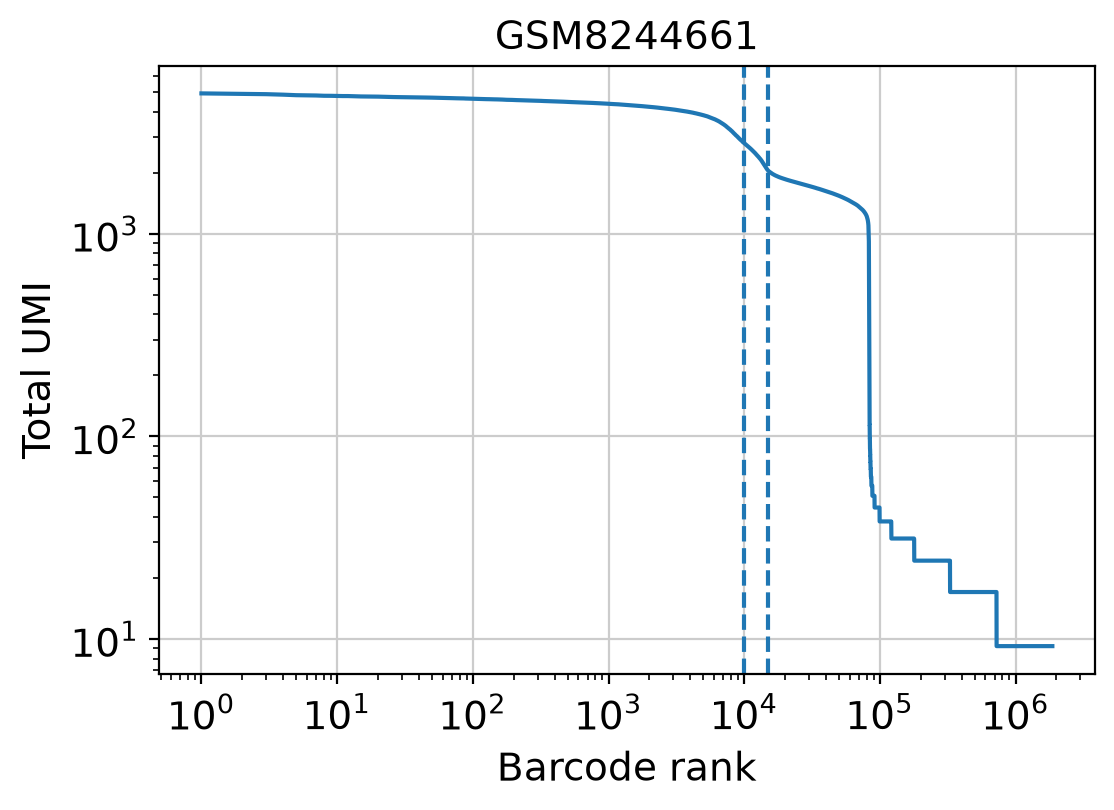

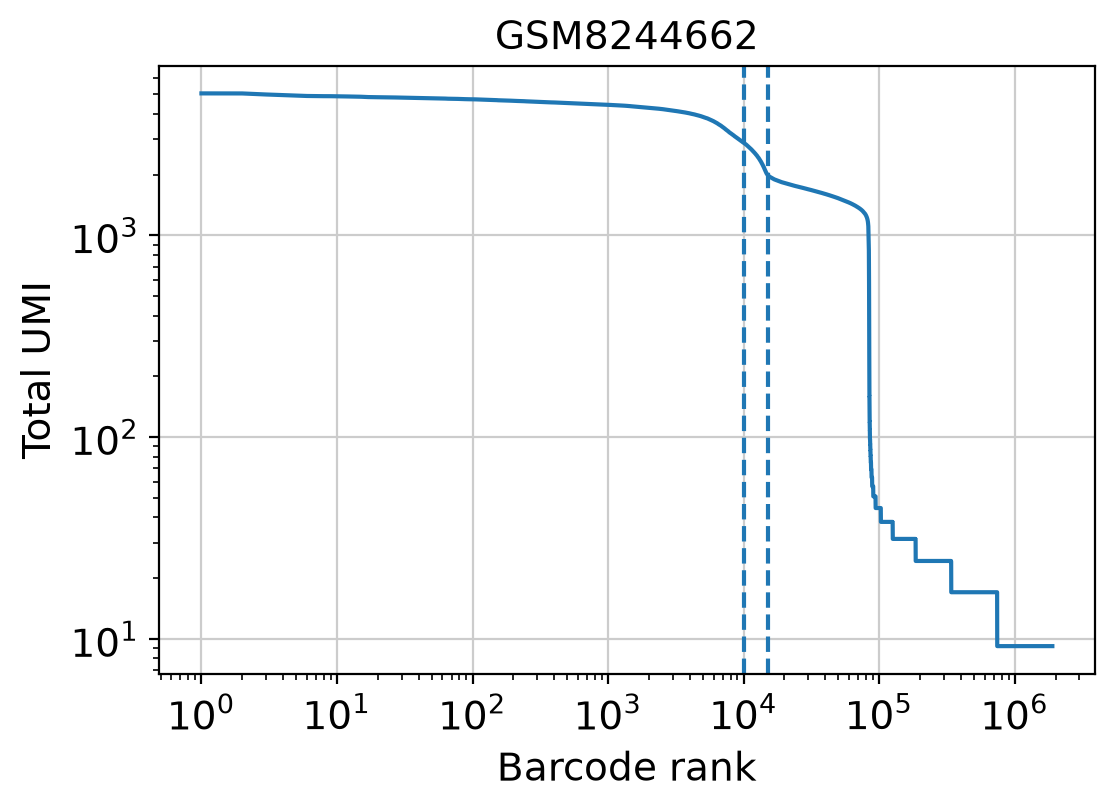

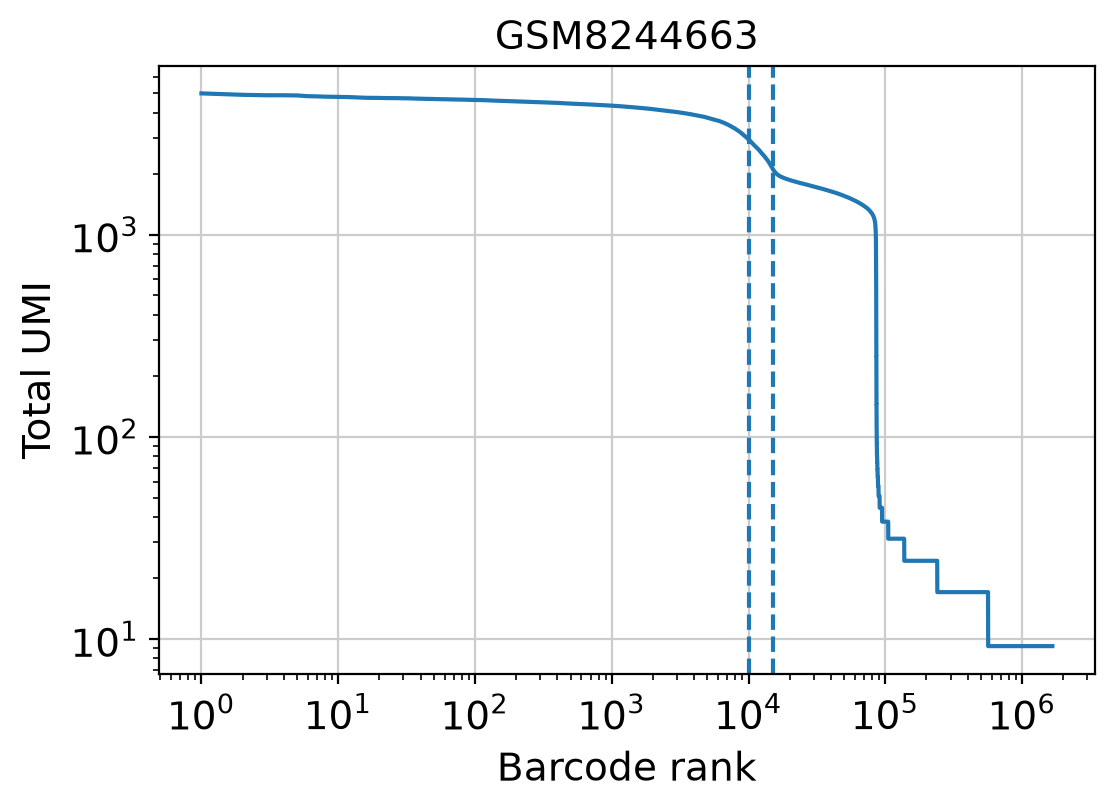

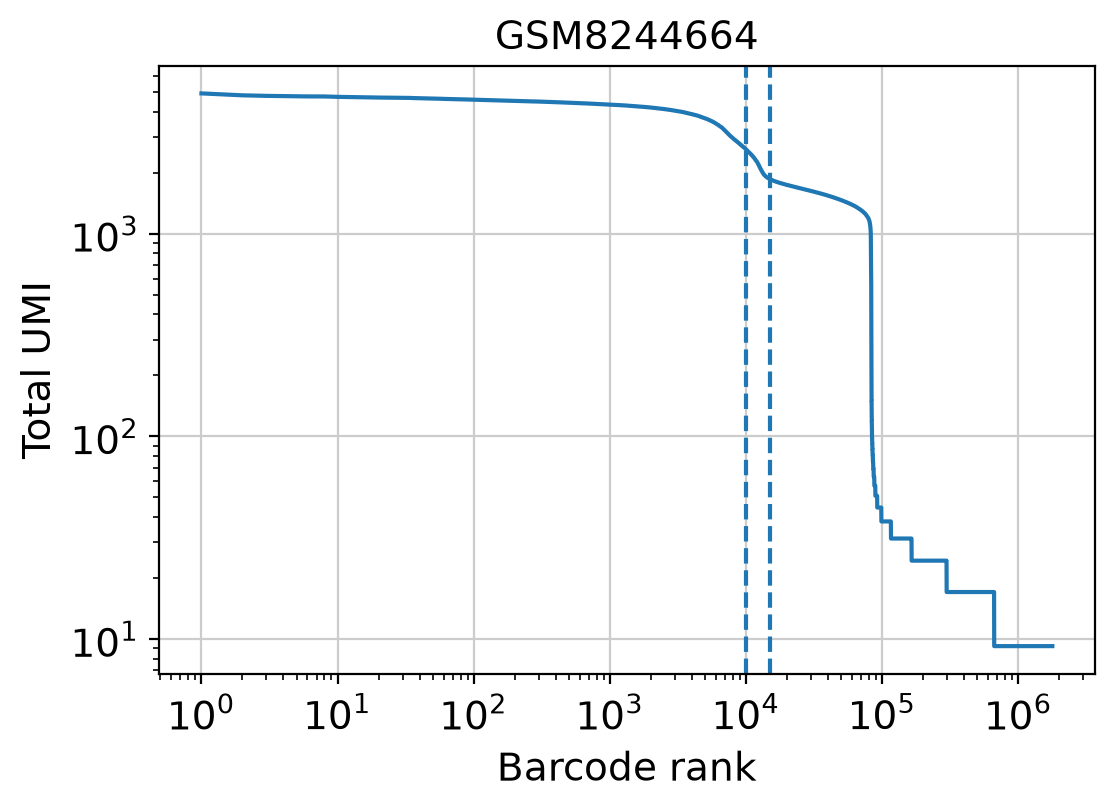

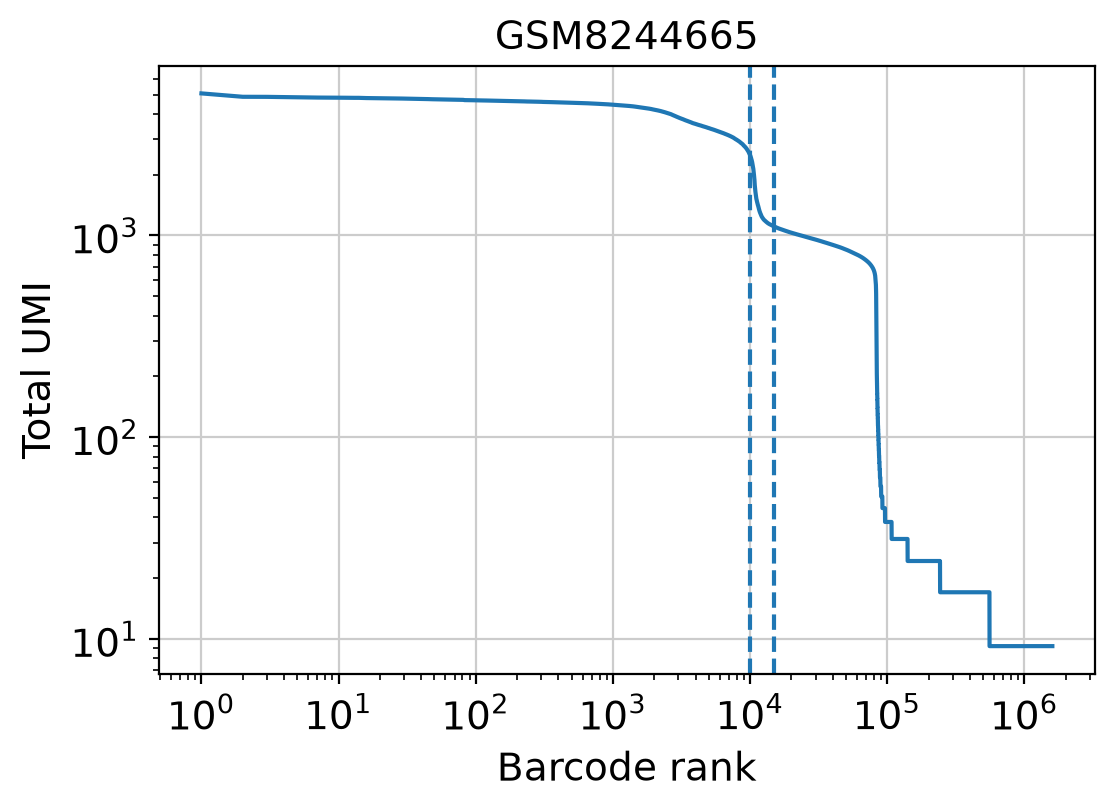

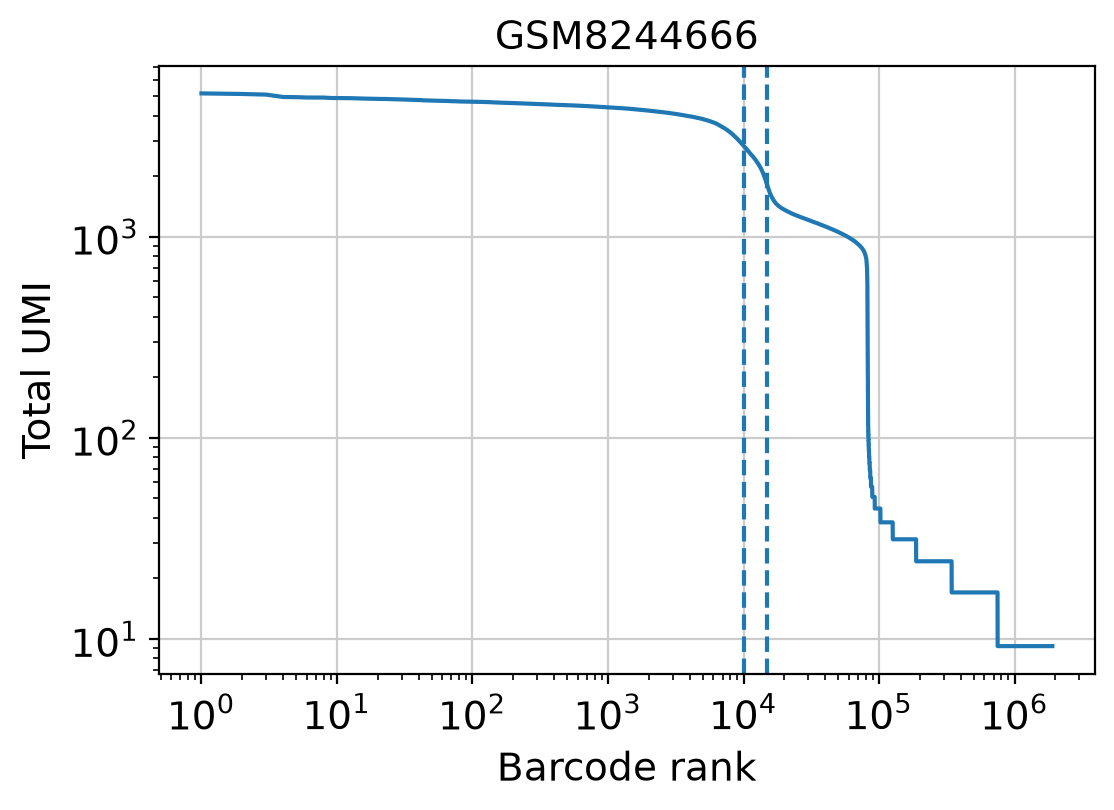

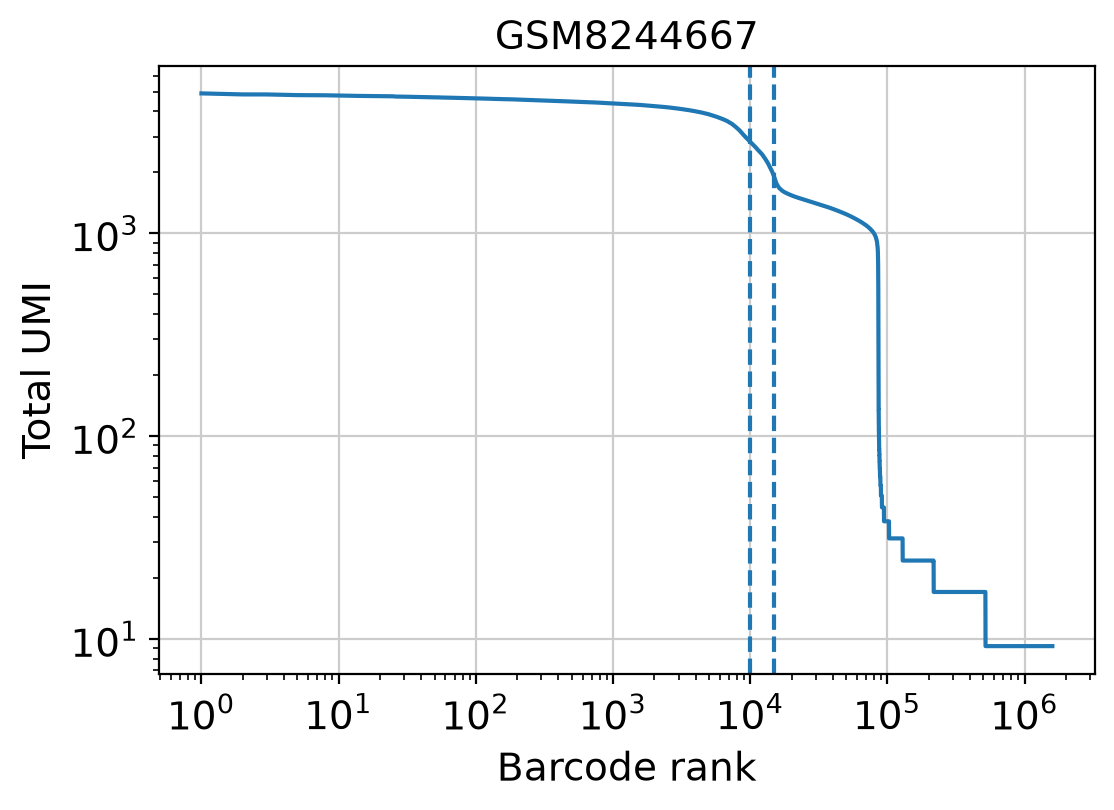

In [12]:
import numpy as np
import matplotlib.pyplot as plt

for gsm in adata.obs["GSM"].unique():
    mask = adata.obs["GSM"] == gsm
    counts = np.asarray(adata[mask].X.sum(axis=1)).ravel()

    counts = np.sort(counts[counts > 0])[::-1]

    plt.figure(figsize=(6, 4))
    plt.loglog(
        np.arange(1, len(counts) + 1),
        counts
    )
    plt.xlabel("Barcode rank")
    plt.ylabel("Total UMI")
    plt.title(gsm)
    plt.axvline(10000, ls="--")
    plt.axvline(15000, ls="--")
    plt.show()

In [13]:
gsm1 = adata.obs_names[adata.obs["GSM"] == "GSM8244661"]
gsm2 = adata.obs_names[adata.obs["GSM"] == "GSM8244662"]

b1 = set(x.rsplit("-GSM", 1)[0] for x in gsm1)
b2 = set(x.rsplit("-GSM", 1)[0] for x in gsm2)

print(len(b1), len(b2))
print("overlap:", len(b1 & b2))

3098997 3088885
overlap: 2131488


In [14]:
import numpy as np

high = {}

for gsm in adata.obs["GSM"].unique():
    mask = np.asarray(adata.obs["GSM"] == gsm)
    counts = np.asarray(adata.X[mask].sum(axis=1)).ravel()

    names = adata.obs_names[mask]
    high[gsm] = set(
        x.rsplit("-GSM", 1)[0]
        for x in names[counts >= 500]
    )

gsms = list(high)

for i in range(len(gsms)):
    for j in range(i + 1, len(gsms)):
        a, b = gsms[i], gsms[j]

        overlap = len(high[a] & high[b])
        print(
            a, b,
            overlap,
            f"{overlap / min(len(high[a]), len(high[b])):.1%}"
        )

GSM8244661 GSM8244662 2007 2.4%
GSM8244661 GSM8244663 2009 2.4%
GSM8244661 GSM8244664 1830 2.2%
GSM8244661 GSM8244665 1882 2.3%
GSM8244661 GSM8244666 1840 2.2%
GSM8244661 GSM8244667 2033 2.4%
GSM8244662 GSM8244663 1983 2.4%
GSM8244662 GSM8244664 1892 2.3%
GSM8244662 GSM8244665 1880 2.3%
GSM8244662 GSM8244666 1965 2.4%
GSM8244662 GSM8244667 1940 2.3%
GSM8244663 GSM8244664 1937 2.3%
GSM8244663 GSM8244665 1968 2.4%
GSM8244663 GSM8244666 1946 2.4%
GSM8244663 GSM8244667 2111 2.5%
GSM8244664 GSM8244665 1840 2.2%
GSM8244664 GSM8244666 1878 2.3%
GSM8244664 GSM8244667 1980 2.4%
GSM8244665 GSM8244666 1944 2.4%
GSM8244665 GSM8244667 1989 2.4%
GSM8244666 GSM8244667 1945 2.4%


In [17]:
adata.obs['donor_id'].value_counts()

donor_id
Control-1    3098997
Control-2    3088885
Patient-1    3000130
Patient-3    2959441
Control-3    2774811
Patient-4    2749412
Patient-2    2482258
Name: count, dtype: int64

### take 2. brute-code liu et al (2024) supp table 1 filtering

In [18]:
import numpy as np
import pandas as pd
import scipy.sparse as sp

# Paper thresholds from Supplementary Table 1
thresholds = {
    "Control-1": {"max_genes": 6500, "max_mt": 5},
    "Control-2": {"max_genes": 7000, "max_mt": 5},
    "Control-3": {"max_genes": 6500, "max_mt": 5},
    "Patient-1": {"max_genes": 6500, "max_mt": 15},
    "Patient-2": {"max_genes": 9000, "max_mt": 30},
    "Patient-3": {"max_genes": 7000, "max_mt": 15},
    "Patient-4": {"max_genes": 6500, "max_mt": 15},
}

# Identify mitochondrial and hemoglobin genes.
# Assumes var_names are currently gene symbols.
genes = adata.var_names.astype(str)

mt_mask = genes.str.upper().str.startswith("MT-")

# Common HB genes; exclude HBP1 etc. by using an explicit list.
hb_genes = {
    "HBA1", "HBA2",
    "HBB", "HBD", "HBE1", "HBG1", "HBG2",
    "HBM", "HBQ1", "HBZ"
}
hb_mask = genes.str.upper().isin(hb_genes)

rows = []

for donor, th in thresholds.items():

    donor_mask = np.asarray(adata.obs["donor_id"] == donor)
    X = adata.X[donor_mask]

    # -------------------------
    # Per-cell statistics
    # -------------------------

    total_counts = np.asarray(X.sum(axis=1)).ravel()

    if sp.issparse(X):
        n_genes = np.asarray((X > 0).sum(axis=1)).ravel()
    else:
        n_genes = (X > 0).sum(axis=1)

    mt_counts = np.asarray(X[:, mt_mask].sum(axis=1)).ravel()
    hb_counts = np.asarray(X[:, hb_mask].sum(axis=1)).ravel()

    with np.errstate(divide="ignore", invalid="ignore"):
        pct_mt = np.divide(
            mt_counts * 100,
            total_counts,
            out=np.zeros_like(mt_counts, dtype=float),
            where=total_counts > 0,
        )

        pct_hb = np.divide(
            hb_counts * 100,
            total_counts,
            out=np.zeros_like(hb_counts, dtype=float),
            where=total_counts > 0,
        )

    # Paper's cell QC
    cell_keep = (
        (n_genes >= 200)
        & (n_genes <= th["max_genes"])
        & (pct_mt <= th["max_mt"])
        & (pct_hb <= 5)
    )

    # -------------------------
    # Gene filtering: min.cells = 3
    # -------------------------

    if sp.issparse(X):
        gene_ncells_before = np.asarray((X > 0).sum(axis=0)).ravel()
        gene_ncells_after = np.asarray(
            (X[cell_keep] > 0).sum(axis=0)
        ).ravel()
    else:
        gene_ncells_before = (X > 0).sum(axis=0)
        gene_ncells_after = (X[cell_keep] > 0).sum(axis=0)

    gene_keep_before = gene_ncells_before >= 3
    gene_keep_after = gene_ncells_after >= 3

    rows.append({
        "donor_id": donor,

        # Current GEO matrix
        "gene_no": X.shape[1],
        "cell_no": X.shape[0],

        # min.cells = 3
        "filtered_genes_before_cell_QC": int(gene_keep_before.sum()),

        # nGene / MT / HB filtering
        "filtered_cells": int(cell_keep.sum()),

        # min.cells = 3 after cell QC
        "filtered_genes_after_cell_QC": int(gene_keep_after.sum()),

        # Useful diagnostics
        "median_nGene_kept": (
            float(np.median(n_genes[cell_keep]))
            if cell_keep.any()
            else np.nan
        ),
    })


sanity_df = pd.DataFrame(rows).set_index("donor_id")

# Paper values for direct comparison
paper_cell_no = {
    "Control-1": 14630,
    "Control-2": 14346,
    "Control-3": 15339,
    "Patient-1": 13123,
    "Patient-2": 11267,
    "Patient-3": 15089,
    "Patient-4": 15356,
}

paper_filtered_cells = {
    "Control-1": 13068,
    "Control-2": 12820,
    "Control-3": 13526,
    "Patient-1": 11716,
    "Patient-2": 10224,
    "Patient-3": 13286,
    "Patient-4": 13518,
}

paper_gene_no = {
    "Control-1": 29967,
    "Control-2": 29956,
    "Control-3": 30004,
    "Patient-1": 29664,
    "Patient-2": 29878,
    "Patient-3": 30193,
    "Patient-4": 30065,
}

sanity_df["paper_gene_no"] = pd.Series(paper_gene_no)
sanity_df["paper_cell_no"] = pd.Series(paper_cell_no)
sanity_df["paper_filtered_cells"] = pd.Series(paper_filtered_cells)

sanity_df

,gene_no,cell_no,filtered_genes_before_cell_QC,filtered_cells,filtered_genes_after_cell_QC,median_nGene_kept,paper_gene_no,paper_cell_no,paper_filtered_cells
donor_id,,,,,,,,,
Control-1,33694,3098997,28695,82972,28590,566.0,29967,14630,13068
Control-2,33694,3088885,28698,83860,28616,553.0,29956,14346,12820
Control-3,33694,2774811,28753,85508,28677,568.0,30004,15339,13526
Patient-1,33694,3000130,28355,82721,28234,524.0,29664,13123,11716
Patient-2,33694,2482258,28208,65689,28036,257.0,29878,11267,10224
Patient-3,33694,2959441,28668,80315,28542,330.0,30193,15089,13286
Patient-4,33694,2749412,28649,85141,28544,409.0,30065,15356,13518


In [9]:
adata.var['gene_symbols'] = adata.var['gene_symbol'].copy()
adata.var.drop(columns=["gene_symbol"], inplace=True)

In [5]:
del adata
adata = sc.read_h5ad(f"/data/SJLEE/Epilepsy_Microglia/notebooks/epilepsy_microglia/data/processed/{dataset}/{dataset}_qc.h5ad")
adata

AnnData object with n_obs × n_vars = 20153934 × 33694
    obs: 'GSM', 'study_id', 'dataset_id', 'species', 'disease_status', 'fcd_subtype', 'driver_mutation_status', 'driver_gene', 'driver_variant', 'mutation_scope', 'brain_region_raw', 'brain_region', 'epilepsy_duration_years', 'sample_source', 'tissue_state', 'cell_or_nucleus', 'platform', 'chemistry', 'raw_counts_available', 'cell_metadata_available', 'genetic_metadata_available', 'main_analysis_eligible', 'exclusion_reason', 'processed_file_format', 'geo_downloadable', 'source_url', 'sample_id', 'donor_id', 'donor_id_global', 'diagnosis_raw', 'diagnosis_harmonized', 'fcd_class', 'mtoropathy_status', 'lesion_position', 'control_type', 'age_years', 'sex', 'n_cells_raw', 'n_cells_qc', 'n_microglia'
    var: 'ensembl_id', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'gene_symbol', 'mapping_status'
    uns: 'hvg', 'log1p'
    layers: 'counts'

In [ ]:
adata.write(f"/data/SJLEE/Epilepsy_Microglia/notebooks/epilepsy_microglia/data/processed/{dataset}/{dataset}.h5ad")

In [21]:
adata = adata[
    :, adata.var["mapping_status"] == "mapped"
].copy()

In [22]:
adata

AnnData object with n_obs × n_vars = 20153934 × 26106
    obs: 'GSM', 'study_id', 'dataset_id', 'species', 'disease_status', 'fcd_subtype', 'driver_mutation_status', 'driver_gene', 'driver_variant', 'mutation_scope', 'brain_region_raw', 'brain_region', 'epilepsy_duration_years', 'sample_source', 'tissue_state', 'cell_or_nucleus', 'platform', 'chemistry', 'raw_counts_available', 'cell_metadata_available', 'genetic_metadata_available', 'main_analysis_eligible', 'exclusion_reason', 'processed_file_format', 'geo_downloadable', 'source_url', 'sample_id', 'donor_id', 'donor_id_global', 'diagnosis_raw', 'diagnosis_harmonized', 'fcd_class', 'mtoropathy_status', 'lesion_position', 'control_type', 'age_years', 'sex', 'n_cells_raw', 'n_cells_qc', 'n_microglia'
    var: 'ensembl_id', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mapping_status', 'gene_symbols'
    uns: 'hvg', 'log1p'
    layers: 'counts'

### take 3. cellranger/emptydrop-like, OrdMag bootstrap (sucess)

In [19]:
adata

AnnData object with n_obs × n_vars = 20153934 × 33694
    obs: 'GSM', 'study_id', 'dataset_id', 'species', 'disease_status', 'fcd_subtype', 'driver_mutation_status', 'driver_gene', 'driver_variant', 'mutation_scope', 'brain_region_raw', 'brain_region', 'epilepsy_duration_years', 'sample_source', 'tissue_state', 'cell_or_nucleus', 'platform', 'chemistry', 'raw_counts_available', 'cell_metadata_available', 'genetic_metadata_available', 'main_analysis_eligible', 'exclusion_reason', 'processed_file_format', 'geo_downloadable', 'source_url', 'sample_id', 'donor_id', 'donor_id_global', 'diagnosis_raw', 'diagnosis_harmonized', 'fcd_class', 'mtoropathy_status', 'lesion_position', 'control_type', 'age_years', 'sex', 'n_cells_raw', 'n_cells_qc', 'n_microglia'
    var: 'ensembl_id', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mapping_status', 'gene_symbols'
    uns: 'hvg', 'log1p'
    layers: 'counts'

In [21]:
adata.obs['GSM'].value_counts()

GSM
GSM8244661    3098997
GSM8244662    3088885
GSM8244664    3000130
GSM8244666    2959441
GSM8244663    2774811
GSM8244667    2749412
GSM8244665    2482258
Name: count, dtype: int64

built 'cr71_call_cells.py' according to OrdMag algorithm that resembles the workflow of CelLRanger 7.10 
to distinguish nuclei from umi rich empty droplets

In [ ]:
# map ordmag barcodes to adata.obs["ordmag"] column, ordmag-only 

from pathlib import Path
import pandas as pd

base = Path(
    "/data/SJLEE/Epilepsy_Microglia/notebooks/epilepsy_microglia/"
    "data/raw/liu_cr71_ordmag-only"
)

adata.obs["ordmag"] = False

for gsm in adata.obs["GSM"].astype(str).unique():

    barcode_file = base / gsm / "ordmag_barcodes.tsv"

    if not barcode_file.exists():
        print(f"[missing] {gsm}: {barcode_file}")
        continue

    ordmag_barcodes = set(
        pd.read_csv(
            barcode_file,
            header=None,
            sep="\t"
        )[0].astype(str)
    )

    sample_mask = adata.obs["GSM"].astype(str) == gsm

    # AAAC...-1-GSM8244662 -> AAAC...-1
    sample_barcodes = (
        adata.obs_names[sample_mask]
        .astype(str)
        .str.replace(f"-{gsm}$", "", regex=True)
    )

    matched = sample_barcodes.isin(ordmag_barcodes)

    adata.obs.loc[sample_mask, "ordmag"] = matched

    print(
        f"{gsm}: "
        f"{matched.sum():,} / {sample_mask.sum():,} GO "
        f"(expected {len(ordmag_barcodes):,})"
    )

GSM8244661: 9,760 / 3,098,997 GO (expected 9,760)
GSM8244662: 9,601 / 3,088,885 GO (expected 9,601)
GSM8244663: 11,149 / 2,774,811 GO (expected 11,149)
GSM8244664: 8,167 / 3,000,130 GO (expected 8,167)
GSM8244665: 4,117 / 2,482,258 GO (expected 4,117)
GSM8244666: 8,641 / 2,959,441 GO (expected 8,641)
GSM8244667: 9,517 / 2,749,412 GO (expected 9,517)


In [ ]:
gsm = "GSM8244662"

barcode_file = base / gsm / "ordmag_barcodes.tsv"

ordmag = pd.read_csv(
    barcode_file,
    header=None,
    sep="\t"
)[0].astype(str)

print("OrdMag:")
print(ordmag.head(10).tolist())

print("\nadata obs_names:")
print(
    adata.obs_names[
        adata.obs["GSM"].astype(str) == gsm
    ][:10].tolist()
)

OrdMag:
['AAACCCAAGAAACTAC-1', 'AAACCCAAGATCACCT-1', 'AAACCCAAGCTGTACT-1', 'AAACCCACAACAGTGG-1', 'AAACCCACACAGTGTT-1', 'AAACCCACACGCCACA-1', 'AAACCCAGTGCTTATG-1', 'AAACCCAGTTCCCACT-1', 'AAACCCAGTTGAATCC-1', 'AAACCCATCCTAAGTG-1']

adata obs_names:
['AAACCCAAGAAACACT-1-GSM8244662', 'AAACCCAAGAAACCAT-1-GSM8244662', 'AAACCCAAGAAACCCA-1-GSM8244662', 'AAACCCAAGAAACCCG-1-GSM8244662', 'AAACCCAAGAAACCTG-1-GSM8244662', 'AAACCCAAGAAACGAA-1-GSM8244662', 'AAACCCAAGAAACTAC-1-GSM8244662', 'AAACCCAAGAAACTCA-1-GSM8244662', 'AAACCCAAGAAACTGC-1-GSM8244662', 'AAACCCAAGAAACTGT-1-GSM8244662']


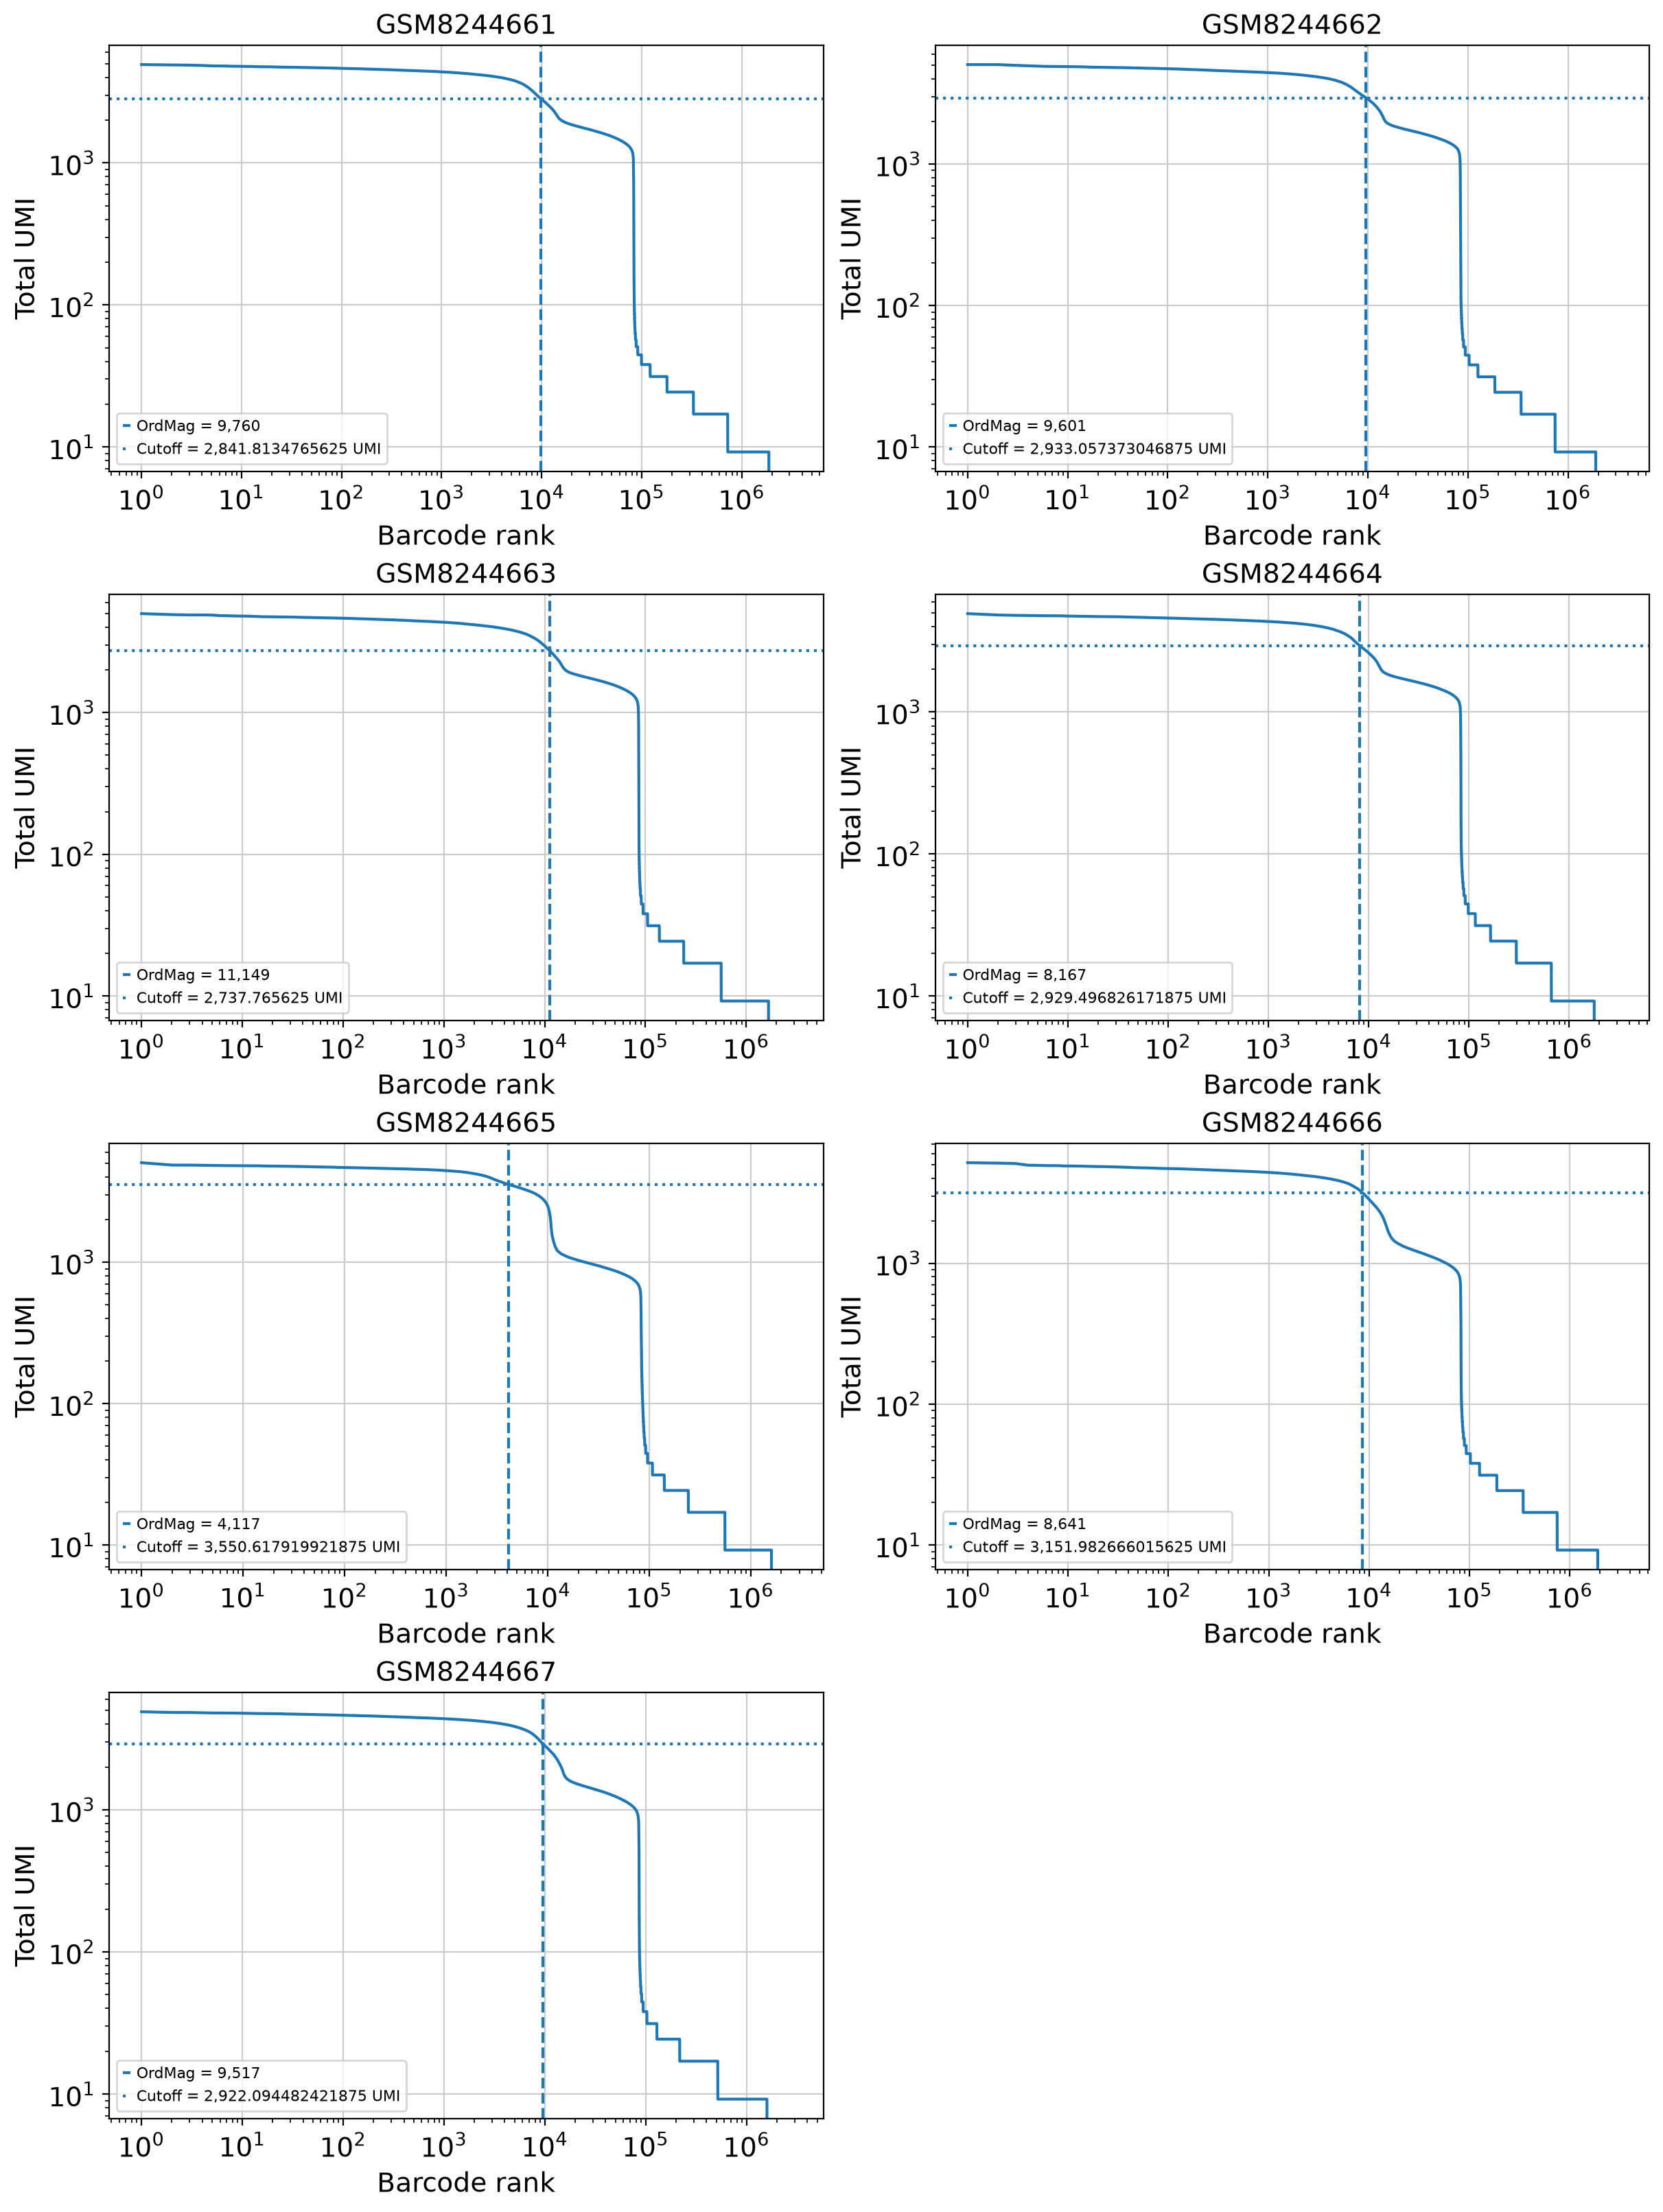

In [ ]:
# plot cliffs : ordmag-only
import numpy as np
import matplotlib.pyplot as plt

gsms = adata.obs["GSM"].astype(str).unique()

fig, axes = plt.subplots(
    4, 2,
    figsize=(12, 16),
    constrained_layout=True
)

axes = axes.flatten()

for ax, gsm in zip(axes, gsms):

    sample_mask = adata.obs["GSM"].astype(str) == gsm
    ad = adata[sample_mask]

    counts = np.asarray(ad.X.sum(axis=1)).ravel()
    counts_sorted = np.sort(counts)[::-1]

    n_ordmag = int(ad.obs["ordmag"].sum())
    umi_cutoff = counts_sorted[n_ordmag - 1]

    ax.loglog(
        np.arange(1, len(counts_sorted) + 1),
        counts_sorted
    )

    ax.axvline(
        n_ordmag,
        linestyle="--",
        label=f"OrdMag = {n_ordmag:,}"
    )

    ax.axhline(
        umi_cutoff,
        linestyle=":",
        label=f"Cutoff = {umi_cutoff:,} UMI"
    )

    ax.set_title(gsm)
    ax.set_xlabel("Barcode rank")
    ax.set_ylabel("Total UMI")
    ax.legend(fontsize=8)


# Remove unused 8th panel
for ax in axes[len(gsms):]:
    ax.remove()

plt.show()

In [27]:
# map ordmag barcodes to adata.obs["final_call"] column
from pathlib import Path
import pandas as pd

base = Path(
    "/data/SJLEE/Epilepsy_Microglia/notebooks/epilepsy_microglia/"
    "data/raw/liu_cr71"
)

adata.obs["final_call"] = False

for gsm in adata.obs["GSM"].astype(str).unique():

    barcode_file = base / gsm / "called_barcodes.tsv"

    if not barcode_file.exists():
        print(f"[missing] {gsm}: {barcode_file}")
        continue

    called_barcodes = set(
        pd.read_csv(
            barcode_file,
            header=None,
            sep="\t"
        )[0].astype(str)
    )

    sample_mask = adata.obs["GSM"].astype(str) == gsm

    # AAAC...-1-GSM8244662 -> AAAC...-1
    sample_barcodes = (
        adata.obs_names[sample_mask]
        .astype(str)
        .str.replace(f"-{gsm}$", "", regex=True)
    )

    matched = sample_barcodes.isin(called_barcodes)

    adata.obs.loc[sample_mask, "final_call"] = matched

    print(
        f"{gsm}: "
        f"{matched.sum():,} / {sample_mask.sum():,} GO "
        f"(expected {len(called_barcodes):,})"
    )

GSM8244661: 14,617 / 3,098,997 GO (expected 14,617)
GSM8244662: 14,245 / 3,088,885 GO (expected 14,245)
GSM8244663: 15,209 / 2,774,811 GO (expected 15,209)
GSM8244664: 13,095 / 3,000,130 GO (expected 13,095)
GSM8244665: 11,262 / 2,482,258 GO (expected 11,262)
GSM8244666: 15,085 / 2,959,441 GO (expected 15,085)
GSM8244667: 15,251 / 2,749,412 GO (expected 15,251)


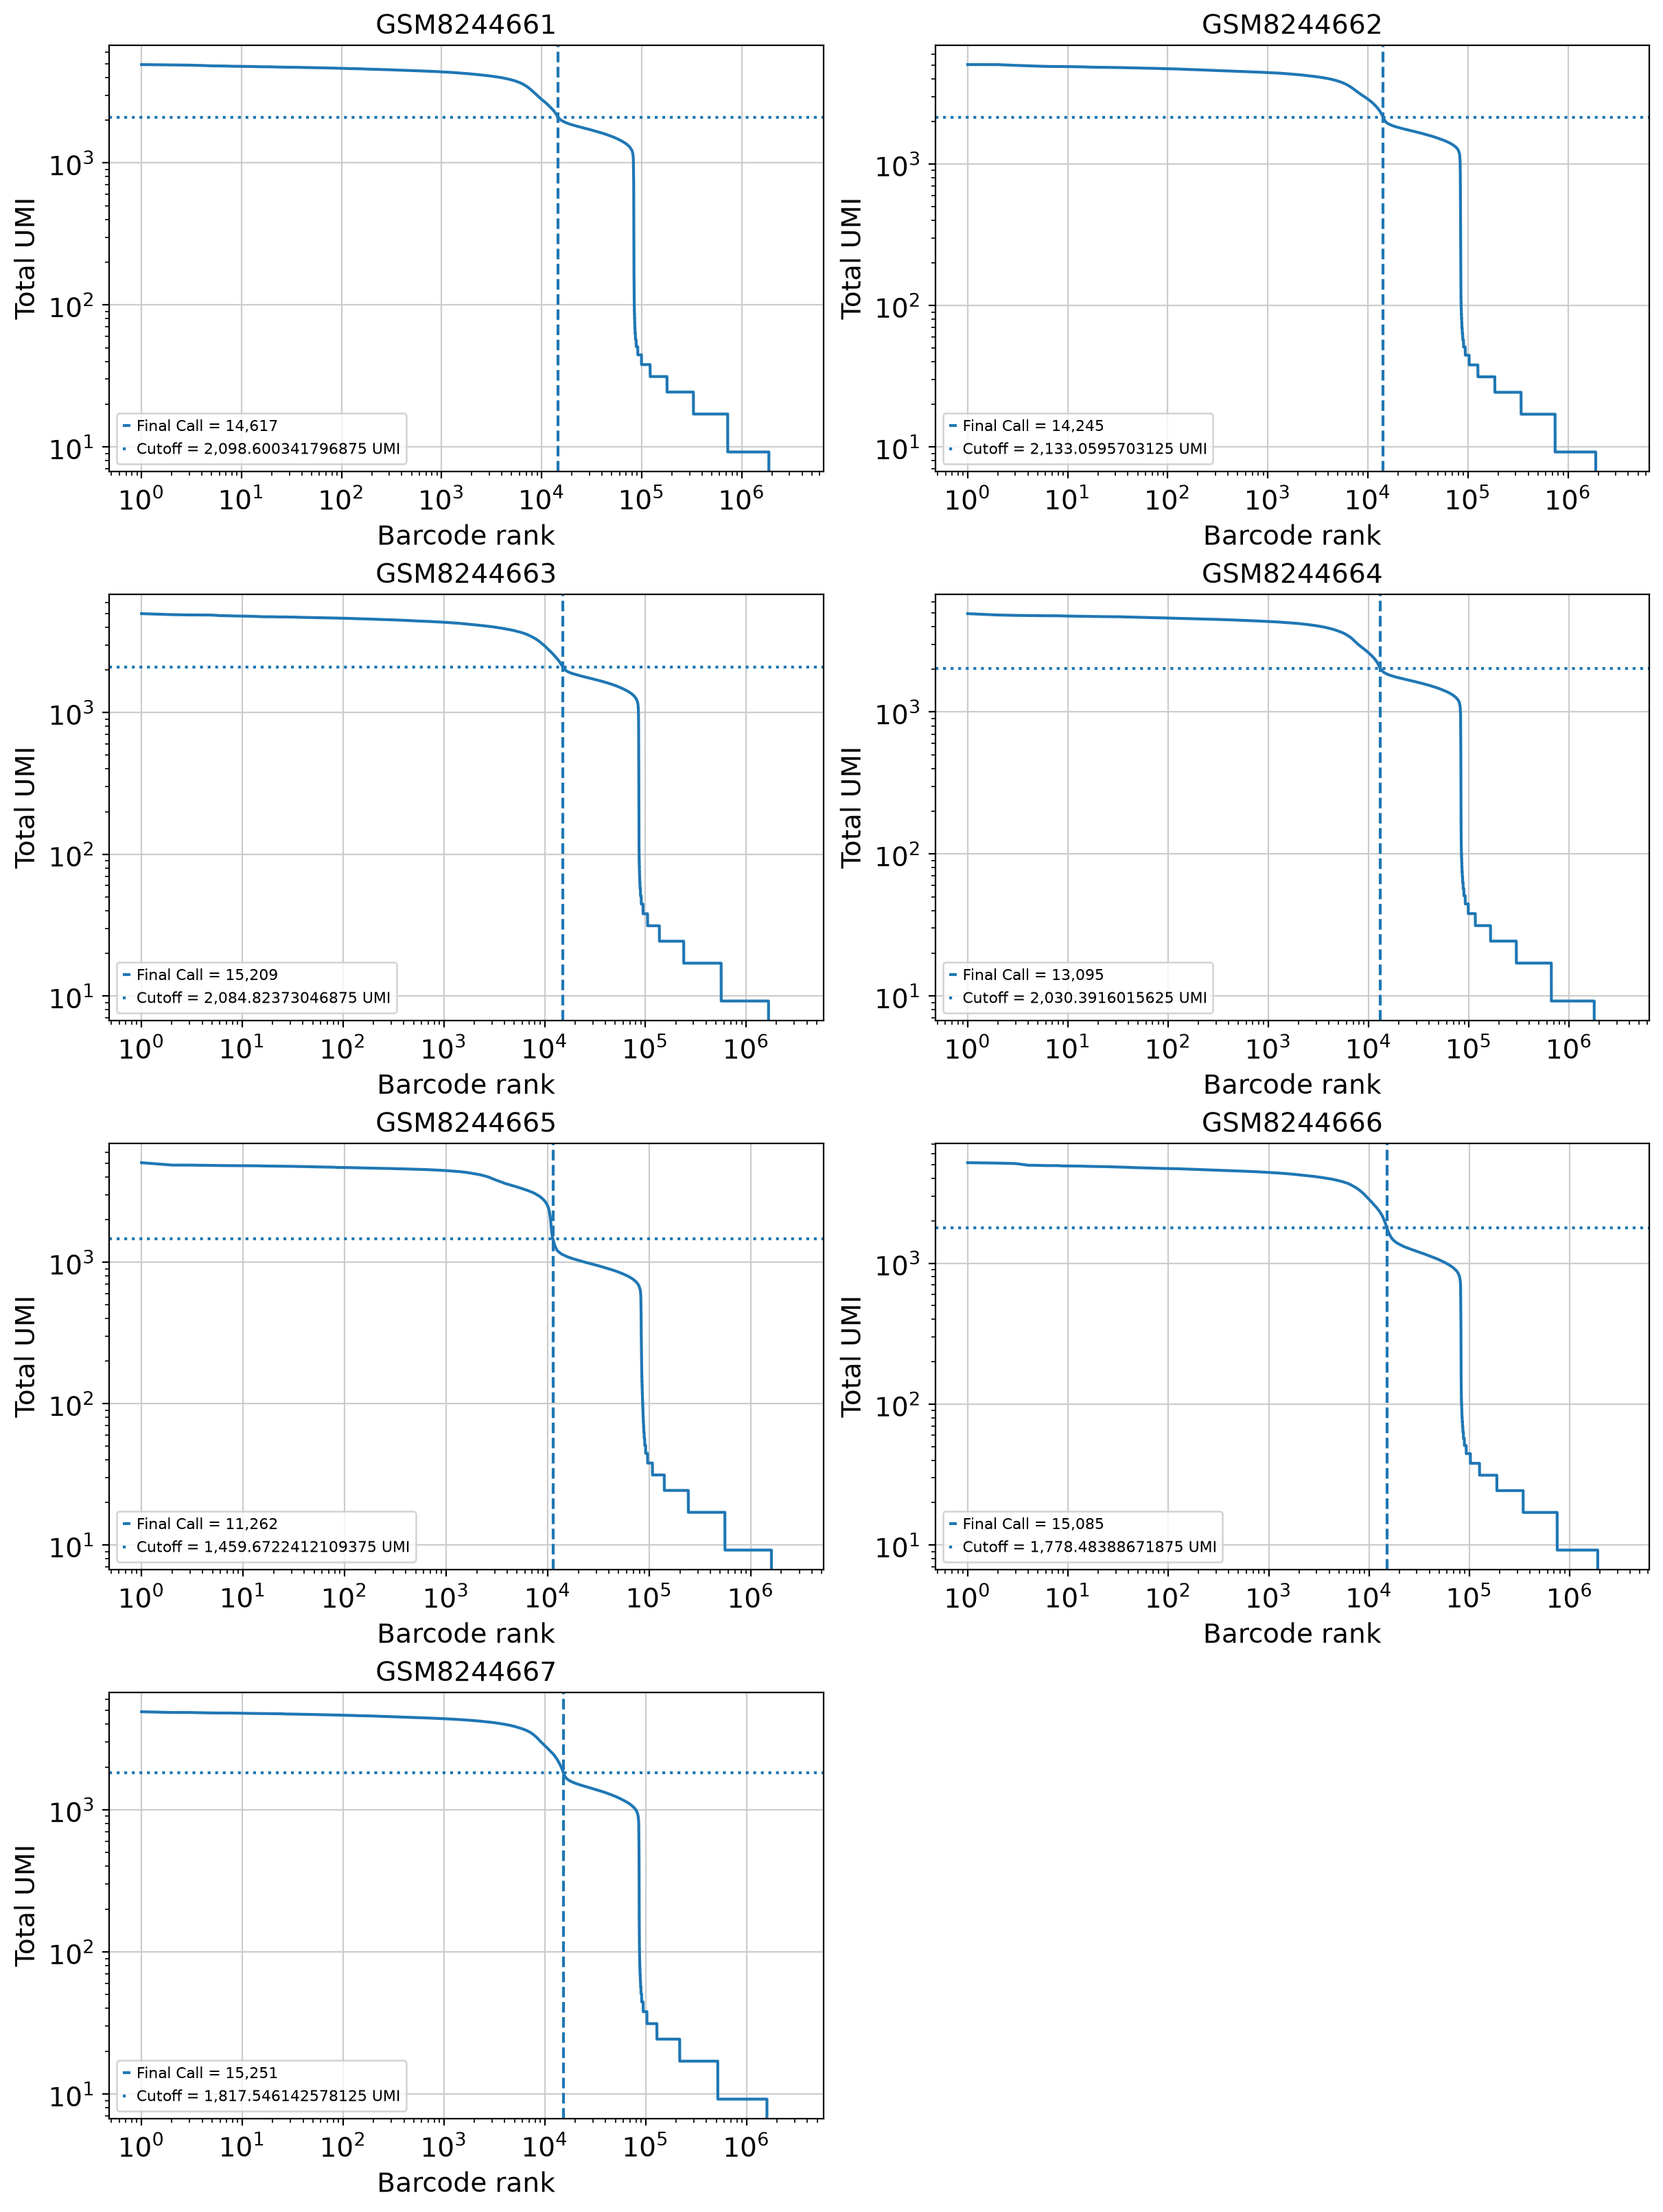

In [28]:
# plot cliffs : final_call
import numpy as np
import matplotlib.pyplot as plt

gsms = adata.obs["GSM"].astype(str).unique()

fig, axes = plt.subplots(
    4, 2,
    figsize=(12, 16),
    constrained_layout=True
)

axes = axes.flatten()

for ax, gsm in zip(axes, gsms):

    sample_mask = adata.obs["GSM"].astype(str) == gsm
    ad = adata[sample_mask]

    counts = np.asarray(ad.X.sum(axis=1)).ravel()
    counts_sorted = np.sort(counts)[::-1]

    n_final_call = int(ad.obs["final_call"].sum())
    umi_cutoff = counts_sorted[n_final_call - 1]

    ax.loglog(
        np.arange(1, len(counts_sorted) + 1),
        counts_sorted
    )

    ax.axvline(
        n_final_call,
        linestyle="--",
        label=f"Final Call = {n_final_call:,}"
    )

    ax.axhline(
        umi_cutoff,
        linestyle=":",
        label=f"Cutoff = {umi_cutoff:,} UMI"
    )

    ax.set_title(gsm)
    ax.set_xlabel("Barcode rank")
    ax.set_ylabel("Total UMI")
    ax.legend(fontsize=8)


# Remove unused 8th panel
for ax in axes[len(gsms):]:
    ax.remove()

plt.show()

In [ ]:
adata.write("/data/SJLEE/Epilepsy_Microglia/notebooks/epilepsy_microglia/data/processed/liu/liu.h5ad")

In [30]:
adata.obs['final_call'].value_counts()

final_call
False    20055170
True        98764
Name: count, dtype: int64

In [31]:
adata = adata[adata.obs["final_call"] == True].copy()
print(adata)

AnnData object with n_obs × n_vars = 98764 × 33694
    obs: 'GSM', 'study_id', 'dataset_id', 'species', 'disease_status', 'fcd_subtype', 'driver_mutation_status', 'driver_gene', 'driver_variant', 'mutation_scope', 'brain_region_raw', 'brain_region', 'epilepsy_duration_years', 'sample_source', 'tissue_state', 'cell_or_nucleus', 'platform', 'chemistry', 'raw_counts_available', 'cell_metadata_available', 'genetic_metadata_available', 'main_analysis_eligible', 'exclusion_reason', 'processed_file_format', 'geo_downloadable', 'source_url', 'sample_id', 'donor_id', 'donor_id_global', 'diagnosis_raw', 'diagnosis_harmonized', 'fcd_class', 'mtoropathy_status', 'lesion_position', 'control_type', 'age_years', 'sex', 'n_cells_raw', 'n_cells_qc', 'n_microglia', 'ordmag', 'final_call'
    var: 'ensembl_id', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mapping_status', 'gene_symbols'
    uns: 'hvg', 'log1p'
    layers: 'counts'


In [33]:
adata.write(f"/data/SJLEE/Epilepsy_Microglia/notebooks/epilepsy_microglia/data/processed/{dataset}/{dataset}_qc.h5ad")

## General Quality Control Pipeline

In [ ]:
adata = sc.read_h5ad(f"/data/SJLEE/Epilepsy_Microglia/notebooks/epilepsy_microglia/data/processed/{dataset}/{dataset}_qc.h5ad")

In [4]:
adata

AnnData object with n_obs × n_vars = 98764 × 33694
    obs: 'GSM', 'study_id', 'dataset_id', 'species', 'disease_status', 'fcd_subtype', 'driver_mutation_status', 'driver_gene', 'driver_variant', 'mutation_scope', 'brain_region_raw', 'brain_region', 'epilepsy_duration_years', 'sample_source', 'tissue_state', 'cell_or_nucleus', 'platform', 'chemistry', 'raw_counts_available', 'cell_metadata_available', 'genetic_metadata_available', 'main_analysis_eligible', 'exclusion_reason', 'processed_file_format', 'geo_downloadable', 'source_url', 'sample_id', 'donor_id', 'donor_id_global', 'diagnosis_raw', 'diagnosis_harmonized', 'fcd_class', 'mtoropathy_status', 'lesion_position', 'control_type', 'age_years', 'sex', 'n_cells_raw', 'n_cells_qc', 'n_microglia', 'ordmag', 'final_call'
    var: 'ensembl_id', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mapping_status', 'gene_symbols'
    uns: 'hvg', 'log1p'
    layers: 'counts'

In [5]:
adata.var

,ensembl_id,highly_variable,means,dispersions,dispersions_norm,mapping_status,gene_symbols
ENSG00000243485,ENSG00000243485,False,5.024650e-04,9.197525,0.501363,mapped,MIR1302-2HG
ENSG00000237613,ENSG00000237613,False,1.000000e-12,NaN,NaN,mapped,FAM138A
ENSG00000186092,ENSG00000186092,False,1.000000e-12,NaN,NaN,mapped,OR4F5
ENSG00000238009,ENSG00000238009,False,9.514761e-03,8.894179,0.370082,unmapped,NaN
ENSG00000239945,ENSG00000239945,False,2.536121e-04,8.495118,0.197378,unmapped,NaN
...,...,...,...,...,...,...,...
ENSG00000277856,ENSG00000277856,False,1.000000e-12,NaN,NaN,unmapped,NaN
ENSG00000275063,ENSG00000275063,False,1.000000e-12,NaN,NaN,mapped,LOC102723407
ENSG00000271254,ENSG00000271254,False,3.479342e-02,8.976587,0.405746,mapped,LOC124905564
ENSG00000277475,ENSG00000277475,False,3.855330e-07,2.050271,-2.591797,unmapped,NaN


In [11]:
adata = adata[:, adata.var['gene_symbols'].notnull()].copy()
adata

AnnData object with n_obs × n_vars = 98764 × 26106
    obs: 'GSM', 'study_id', 'dataset_id', 'species', 'disease_status', 'fcd_subtype', 'driver_mutation_status', 'driver_gene', 'driver_variant', 'mutation_scope', 'brain_region_raw', 'brain_region', 'epilepsy_duration_years', 'sample_source', 'tissue_state', 'cell_or_nucleus', 'platform', 'chemistry', 'raw_counts_available', 'cell_metadata_available', 'genetic_metadata_available', 'main_analysis_eligible', 'exclusion_reason', 'processed_file_format', 'geo_downloadable', 'source_url', 'sample_id', 'donor_id', 'donor_id_global', 'diagnosis_raw', 'diagnosis_harmonized', 'fcd_class', 'mtoropathy_status', 'lesion_position', 'control_type', 'age_years', 'sex', 'n_cells_raw', 'n_cells_qc', 'n_microglia', 'ordmag', 'final_call'
    var: 'ensembl_id', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mapping_status', 'gene_symbols', 'mt', 'ribo', 'hb'
    uns: 'hvg', 'log1p'
    layers: 'counts'

In [12]:
adata.var_names_make_unique()

adata.var["mt"] = adata.var['gene_symbols'].str.upper().str.startswith("MT-")
adata.var["ribo"] = adata.var['gene_symbols'].str.upper().str.startswith(("RPS", "RPL"))
adata.var["hb"] = adata.var['gene_symbols'].str.upper().str.startswith(
    ("HBA", "HBB", "HBD", "HBE", "HBG", "HBM", "HBQ", "HBZ")
)

sc.pp.calculate_qc_metrics(
    adata,
    qc_vars=["mt", "ribo", "hb"],
    inplace=True,
    percent_top=[20],
    log1p=True,
)

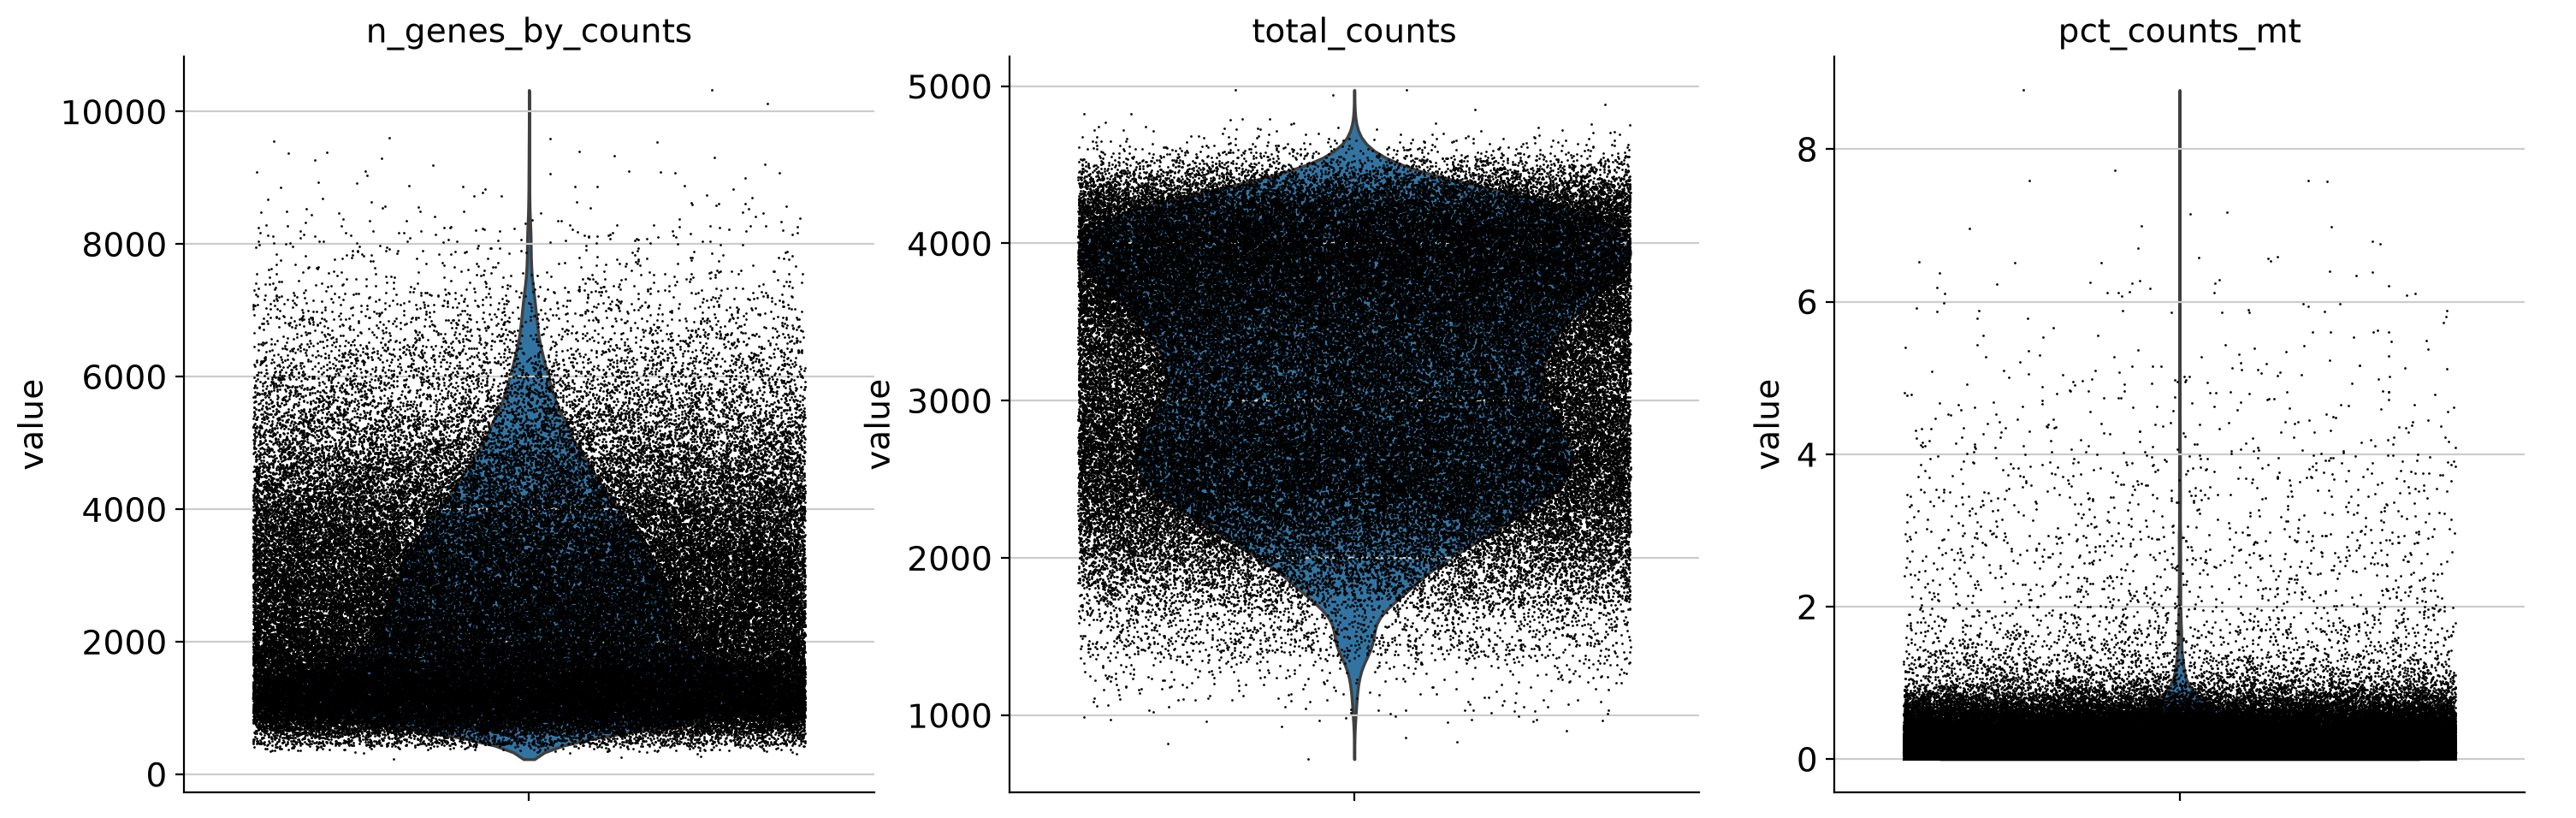

In [13]:
sc.pl.violin(adata, ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'],
             jitter=0.4, multi_panel=True)

,sample_id,donor_id,total_counts,n_genes_by_counts
AAACCCAAGAGCAACC-1-GSM8244661,Control-1_snRNA,Control-1,12936.0,4735
AAACCCAAGGCCATAG-1-GSM8244661,Control-1_snRNA,Control-1,2286.0,1447
AAACCCAAGGCCCGTT-1-GSM8244661,Control-1_snRNA,Control-1,7285.0,3322
AAACCCACACATGACT-1-GSM8244661,Control-1_snRNA,Control-1,11491.0,4202
AAACCCACACTATCGA-1-GSM8244661,Control-1_snRNA,Control-1,5491.0,2750


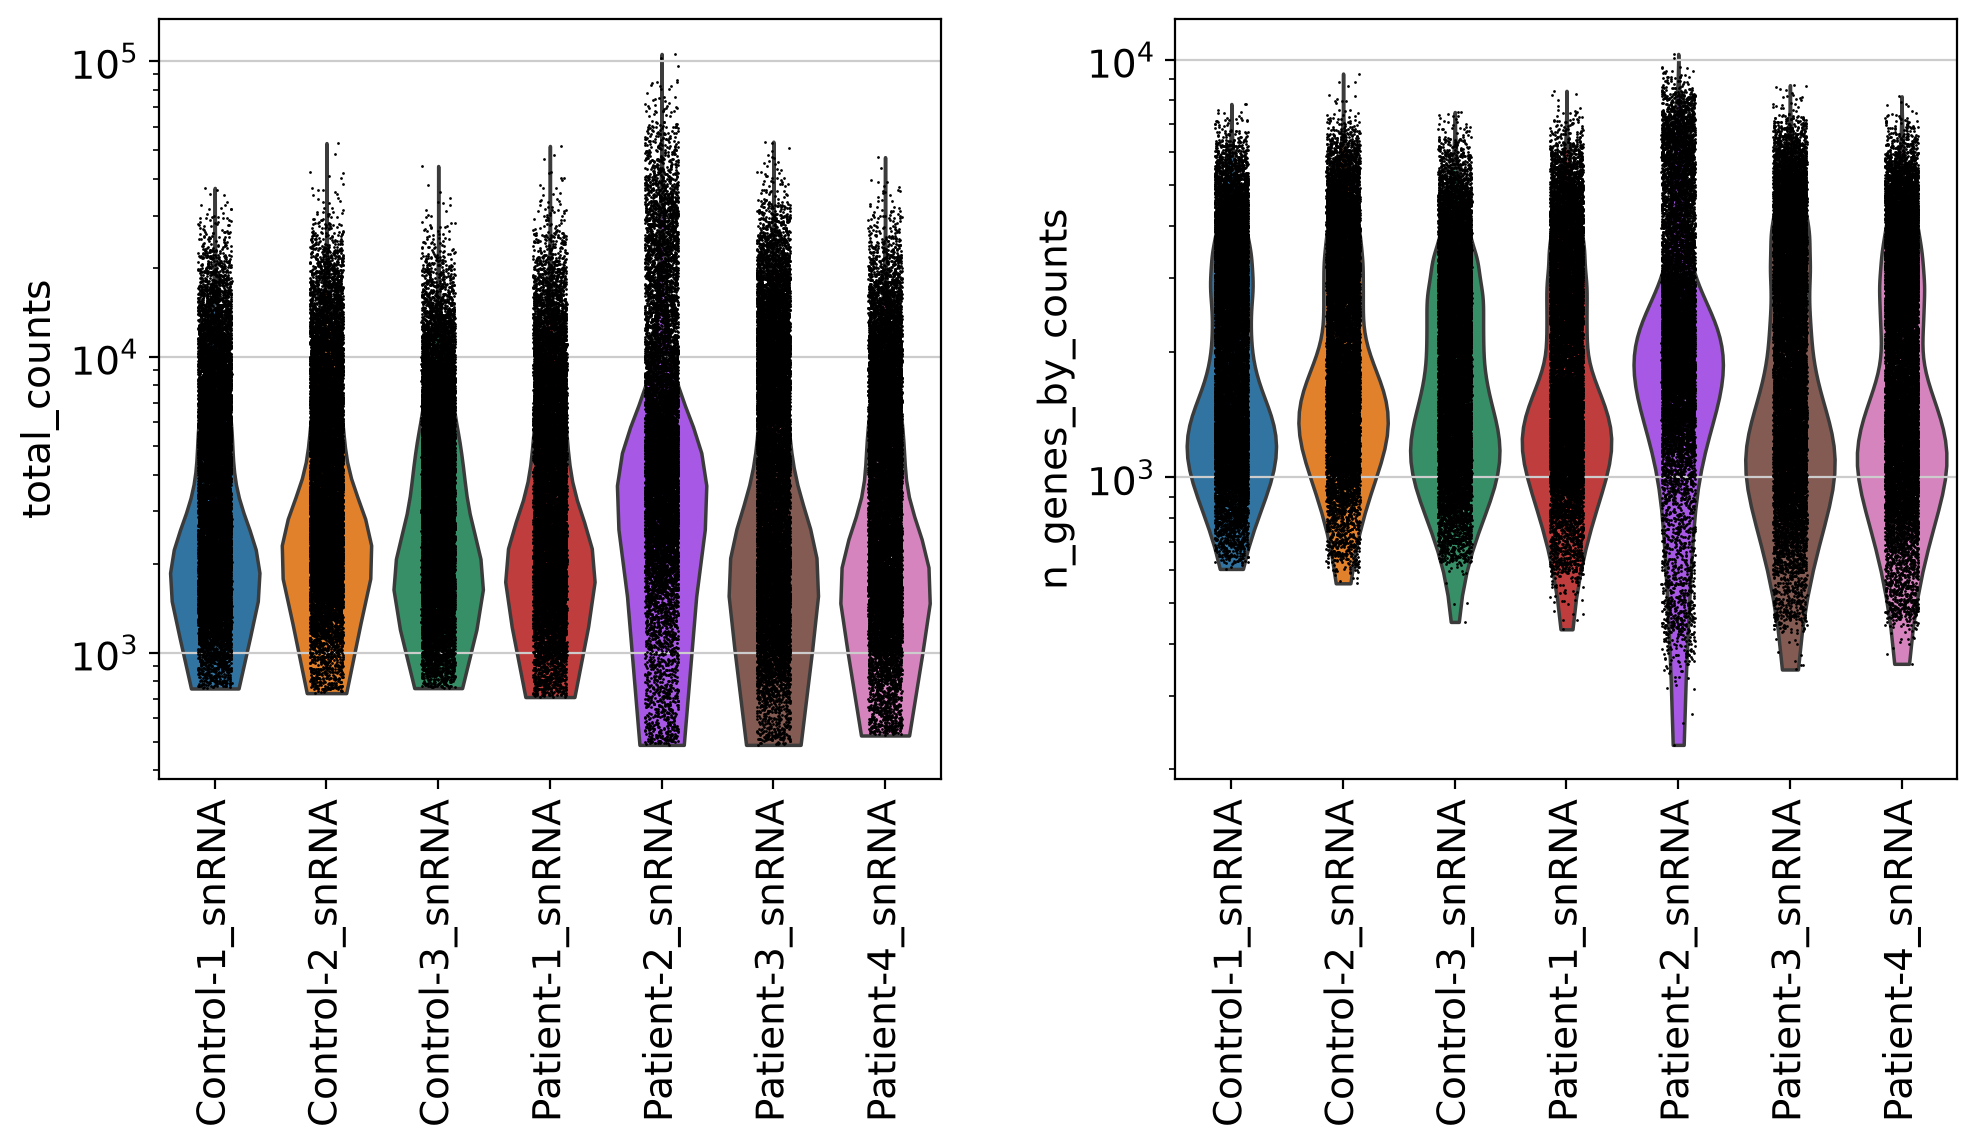

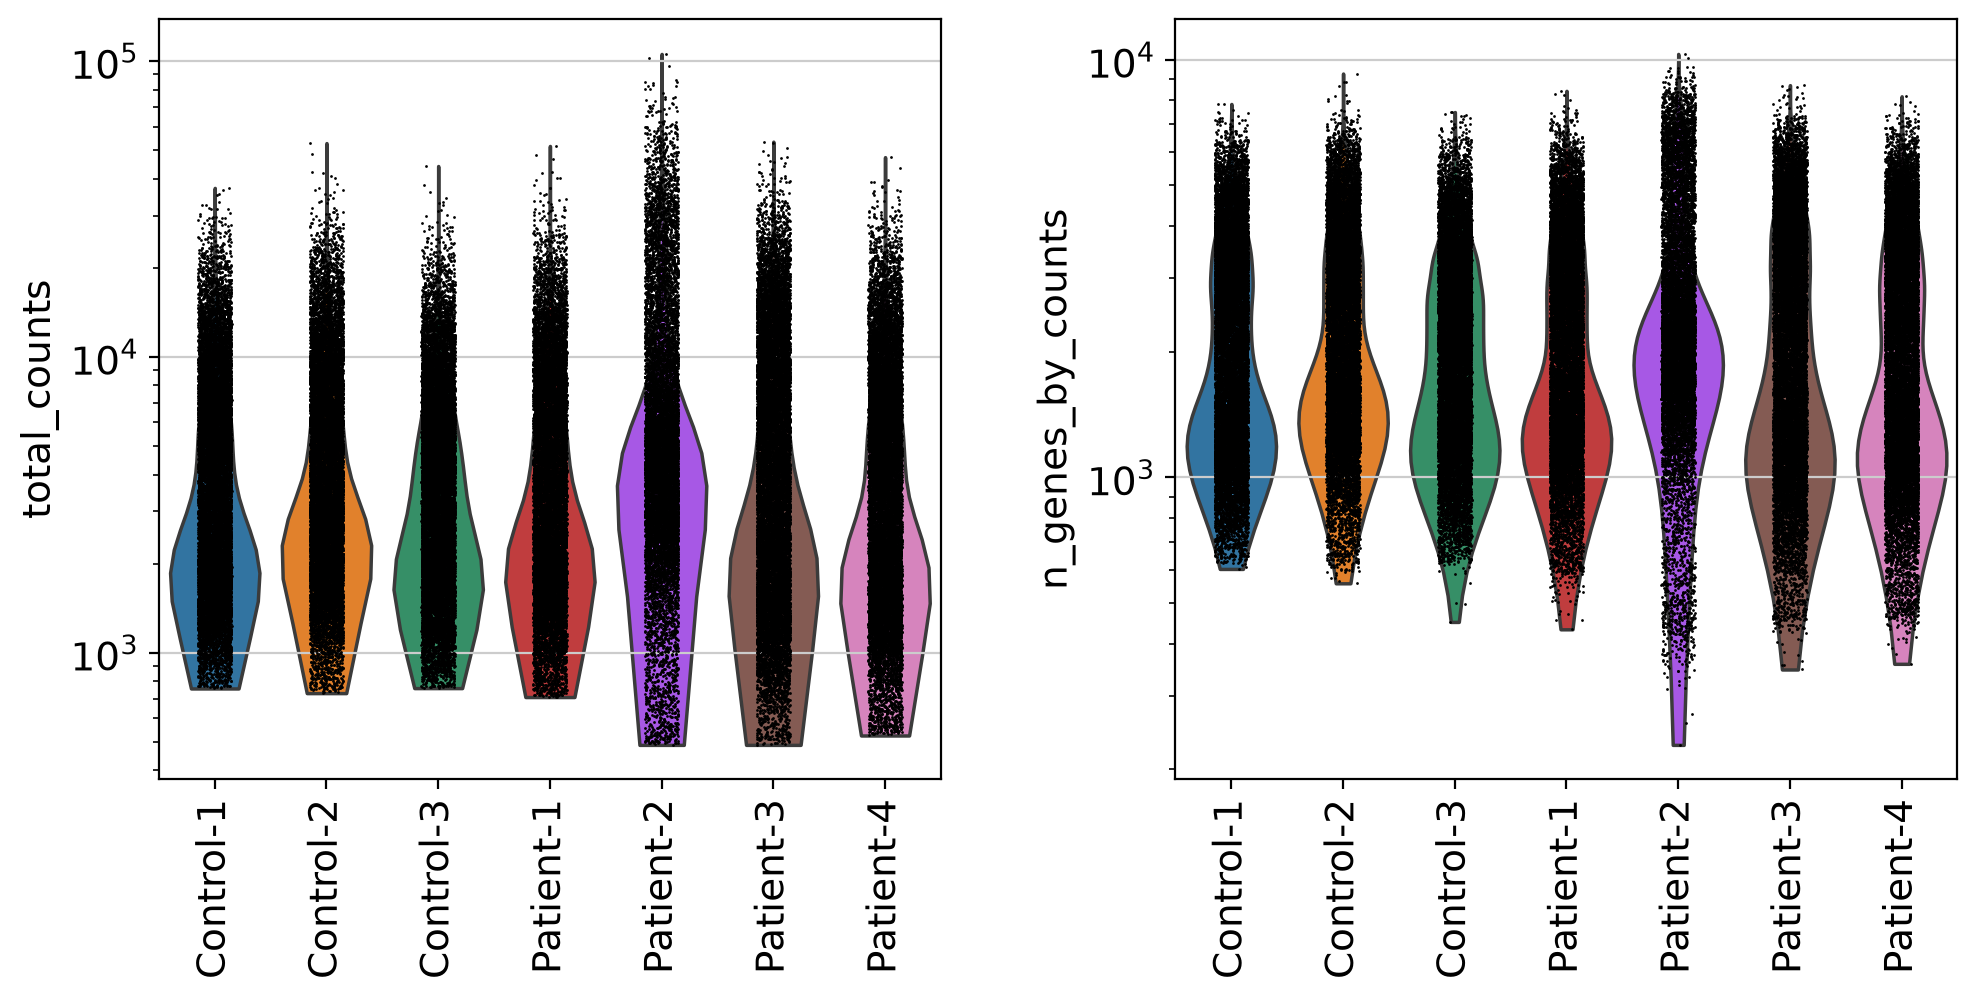

In [14]:
# check donor/sample-level qc metrics

import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt

# Use the raw-count layer if present; otherwise use adata.X.
count_layer = "counts" if "counts" in adata.layers else None

sc.pp.calculate_qc_metrics(
    adata,
    layer=count_layer,
    inplace=True,
    log1p=False,
)

# Confirm these exist before plotting.
display(
    adata.obs[
        ["sample_id", "donor_id", "total_counts", "n_genes_by_counts"]
    ].head()
)

for groupby in ["sample_id", "donor_id"]:
    if groupby not in adata.obs.columns:
        print(f"Skipping {groupby}: column not found.")
        continue

    sc.pl.violin(
        adata,
        keys=["total_counts", "n_genes_by_counts"],
        groupby=groupby,
        layer=count_layer,
        log=True,          # easier to see the low-count nuclear tail
        jitter=0.15,
        rotation=90,
        multi_panel=True,
        show=True,
    )

In [15]:
cutoffs = pd.DataFrame(
    {
        "counts≥500": adata.obs["total_counts"] >= 500,
        "counts≥1000": adata.obs["total_counts"] >= 1000,
        "counts≥2000": adata.obs["total_counts"] >= 2000,
        "genes≥250": adata.obs["n_genes_by_counts"] >= 250,
        "genes≥500": adata.obs["n_genes_by_counts"] >= 500,
    },
    index=adata.obs_names,
)

retention_by_sample = (
    cutoffs
    .join(adata.obs["sample_id"])
    .groupby("sample_id", observed=True)
    .mean()
    .mul(100)
    .round(1)
)

display(retention_by_sample)

,counts≥500,counts≥1000,counts≥2000,genes≥250,genes≥500
sample_id,,,,,
Control-1_snRNA,100.0,97.0,72.2,100.0,100.0
Control-2_snRNA,100.0,97.7,77.8,100.0,100.0
Control-3_snRNA,100.0,96.4,74.0,100.0,100.0
Patient-1_snRNA,100.0,95.7,71.9,100.0,99.9
Patient-2_snRNA,99.9,95.3,86.0,100.0,97.6
Patient-3_snRNA,99.9,93.0,70.7,100.0,99.1
Patient-4_snRNA,100.0,93.2,69.9,100.0,99.0


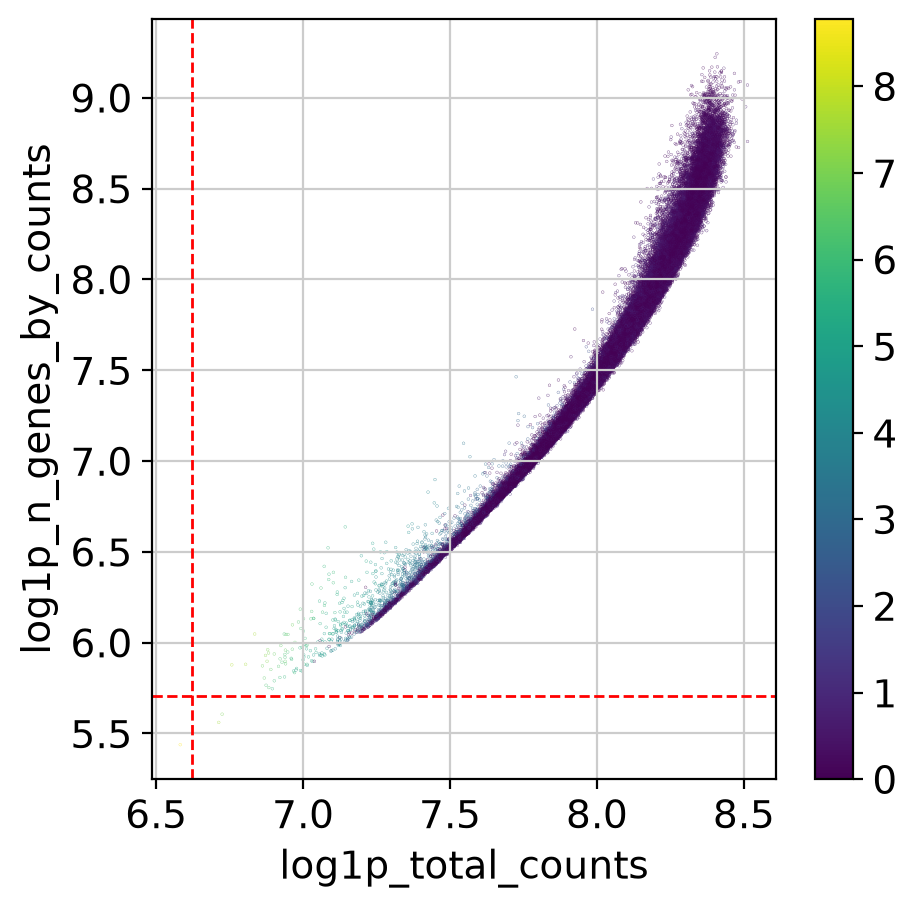

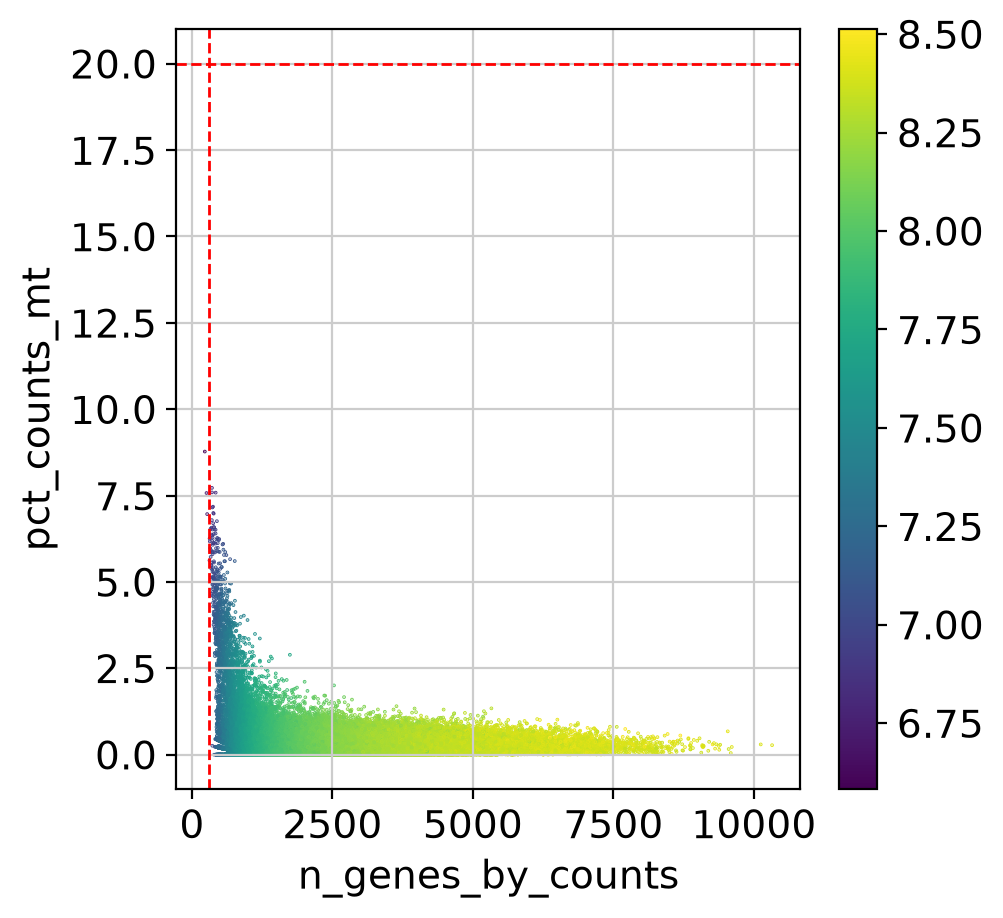

In [16]:
plt.scatter(adata.obs['log1p_total_counts'], adata.obs['log1p_n_genes_by_counts'], c=adata.obs['pct_counts_mt'], s=0.01)
plt.axvline(x=np.log1p(750), color='r', linestyle='--', linewidth=1) # min_counts
plt.axhline(y=np.log1p(300), color='r', linestyle='--', linewidth=1) # min_genes
#plt.axhline(y=np.log1p(7000), color='r', linestyle='--', linewidth=1) # max_genes
plt.xlabel('log1p_total_counts')
plt.ylabel('log1p_n_genes_by_counts')
plt.colorbar()
plt.show()

plt.scatter(adata.obs['n_genes_by_counts'], adata.obs['pct_counts_mt'], c=adata.obs['log1p_total_counts'], s=0.1)
plt.axvline(x=300, color='r', linestyle='--', linewidth=1) # min_genes
#plt.axvline(x=7000, color='r', linestyle='--', linewidth=1) # max_genes
plt.axhline(y=20, color='r', linestyle='--', linewidth=1) # max_mt
plt.xlabel('n_genes_by_counts')
plt.ylabel('pct_counts_mt')
plt.colorbar()
plt.show()

In [17]:
# doublet detection

scrub = scr.Scrublet(adata.X)
scores, predicted = scrub.scrub_doublets(verbose=False)

adata.obs["doublet_scores"] = scores
adata.obs["predicted_doublets"] = predicted

print(adata.obs["predicted_doublets"].value_counts())

/home/lsj1022/anaconda3/envs/scenv/lib/python3.11/site-packages/scrublet/helper_functions.py:239: RuntimeWarning: invalid value encountered in log
  gLog = lambda input: np.log(input[1] * np.exp(-input[0]) + input[2])
/home/lsj1022/anaconda3/envs/scenv/lib/python3.11/site-packages/scrublet/helper_functions.py:252: RuntimeWarning: invalid value encountered in sqrt
  CV_input = np.sqrt(b);


predicted_doublets
False    93925
True      4839
Name: count, dtype: int64


In [18]:
#sc.pp.filter_cells(adata, min_counts=500) 
sc.pp.filter_cells(adata, min_genes=300)
#sc.pp.filter_cells(adata, max_genes=7000) 
adata = adata[adata.obs['pct_counts_mt'] < 20, :] # 20% 이상의 mitochondria 분율을 가진 Sample 제외 (doublet 일 수 있음)

filtered out 3 cells that have less than 300 genes expressed


In [19]:
adata = adata[~adata.obs["predicted_doublets"]].copy()

In [20]:
adata

AnnData object with n_obs × n_vars = 93922 × 26106
    obs: 'GSM', 'study_id', 'dataset_id', 'species', 'disease_status', 'fcd_subtype', 'driver_mutation_status', 'driver_gene', 'driver_variant', 'mutation_scope', 'brain_region_raw', 'brain_region', 'epilepsy_duration_years', 'sample_source', 'tissue_state', 'cell_or_nucleus', 'platform', 'chemistry', 'raw_counts_available', 'cell_metadata_available', 'genetic_metadata_available', 'main_analysis_eligible', 'exclusion_reason', 'processed_file_format', 'geo_downloadable', 'source_url', 'sample_id', 'donor_id', 'donor_id_global', 'diagnosis_raw', 'diagnosis_harmonized', 'fcd_class', 'mtoropathy_status', 'lesion_position', 'control_type', 'age_years', 'sex', 'n_cells_raw', 'n_cells_qc', 'n_microglia', 'ordmag', 'final_call', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_

In [21]:
adata.write(f"/data/SJLEE/Epilepsy_Microglia/notebooks/epilepsy_microglia/data/processed/{dataset}/{dataset}_qc.h5ad")

# 2. Preprocess

In [28]:
adata= sc.read_h5ad(f"/data/SJLEE/Epilepsy_Microglia/notebooks/epilepsy_microglia/data/processed/{dataset}/{dataset}_qc.h5ad")

In [22]:
adata.layers['counts'] = adata.X.copy()

In [29]:
print(adata.layers['counts'].max())
print(adata.layers['counts'].min())

2846.0
0.0


In [30]:
adata.X = adata.layers['counts'].copy()

In [31]:
# normalization

print('before log1p norm')
print('max: ', np.max(adata.X))
print('min: ', np.min(adata.X))
print('mean: ', np.mean(adata.X))

adata.var_names_make_unique()
adata.obs_names_make_unique()

# Normalization : Sample 에서 세포 합이 모두 100,00 이 되도록 함 (Sample 간의 비교를 위해)
sc.pp.normalize_total(adata, target_sum=1e4)

# Matrix 가 잘 정규화 되었는지 확인
adata.X.sum(axis=1)

# Logarithmize
sc.pp.log1p(adata)
adata.raw = adata
print('after log1p norm')
print('max: ', np.max(adata.X))
print('min: ', np.min(adata.X))
print('mean: ', np.mean(adata.X))

before log1p norm
max:  2846.0
min:  0.0
mean:  0.22370696
normalizing counts per cell
    finished (0:00:00)
after log1p norm
max:  7.333222
min:  0.0
mean:  0.12431077


extracting highly variable genes
    finished (0:00:02)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)


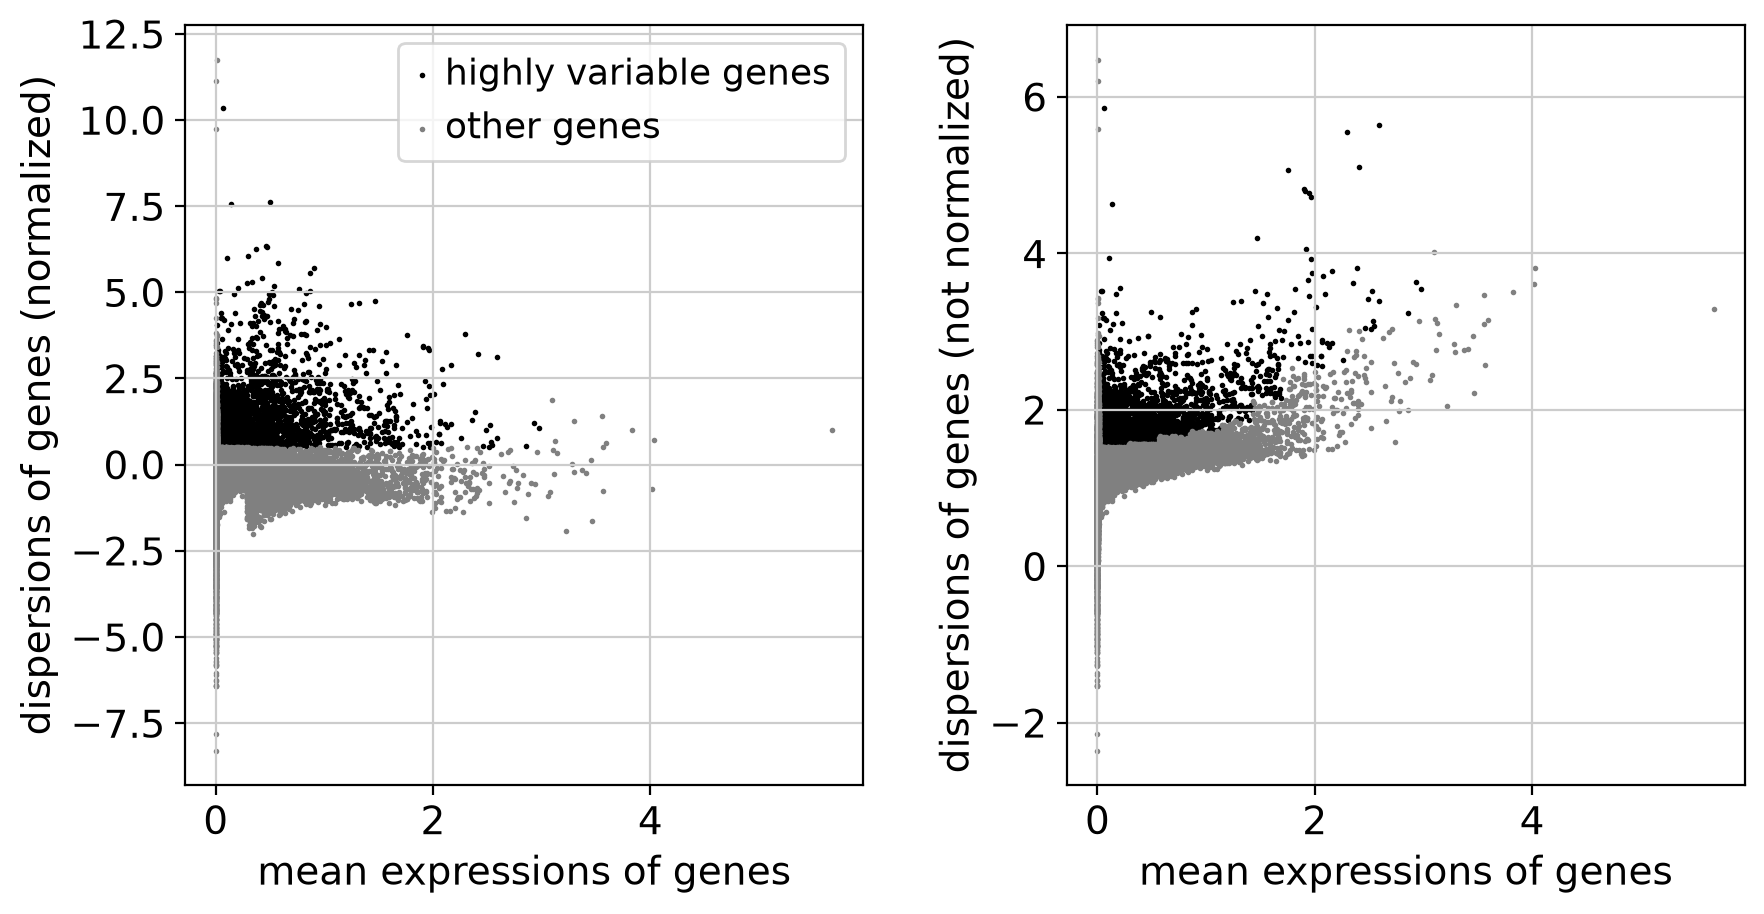

detected 3581 highly variable genes


/home/lsj1022/anaconda3/envs/scenv/lib/python3.11/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


In [32]:
# HVG (Highly variable genes) : adata 에서 어떤 Gene 들이 많이 차이가 나는지 확인
sc.pp.highly_variable_genes(adata) # adata 에서 HVG 에 해당하는 Gene 갯수를 확인
sc.pl.highly_variable_genes(adata)
print(f"detected {np.sum(adata.var['highly_variable'])} highly variable genes")

sc.pp.scale(adata, max_value=10)

In [ ]:
adata.write(f"/data/SJLEE/Epilepsy_Microglia/notebooks/epilepsy_microglia/data/processed/{dataset}/{dataset}_qc.h5ad")

# 3. Feature Selecetion

computing PCA
    with n_comps=50
    finished (0:00:16)


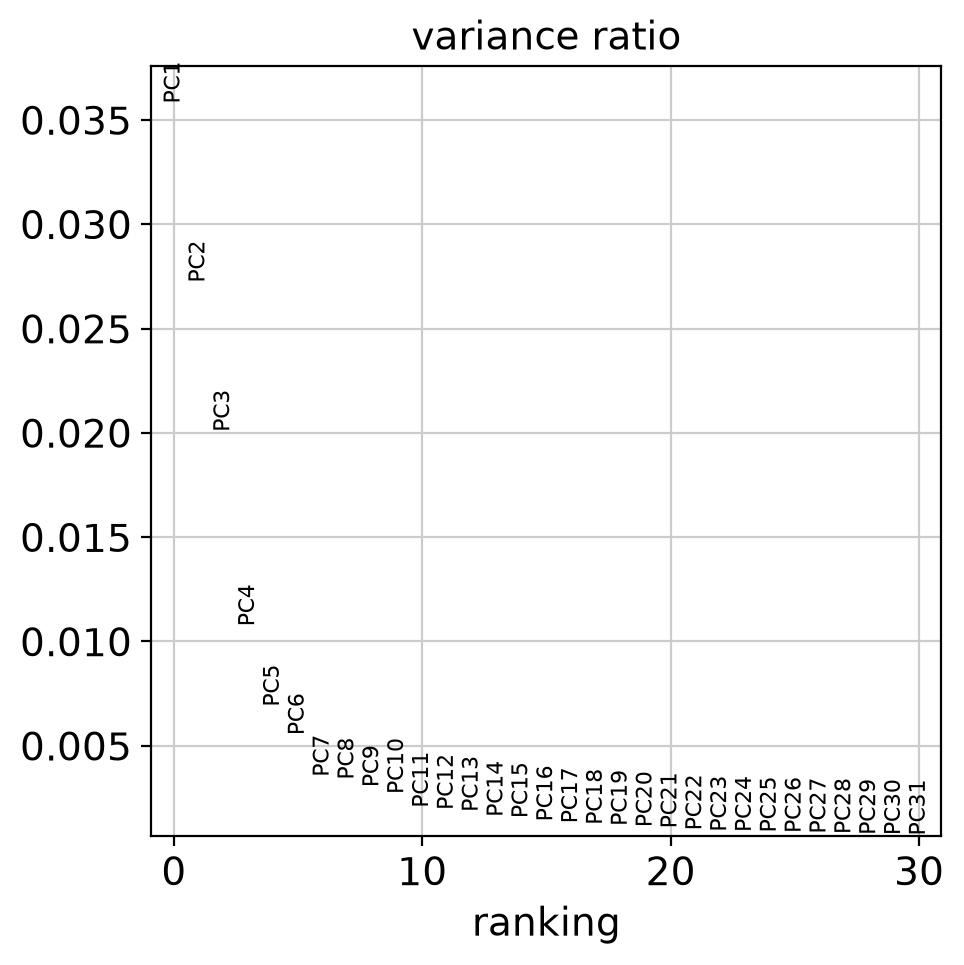

In [33]:
sc.tl.pca(adata)
sc.pl.pca_variance_ratio(adata)

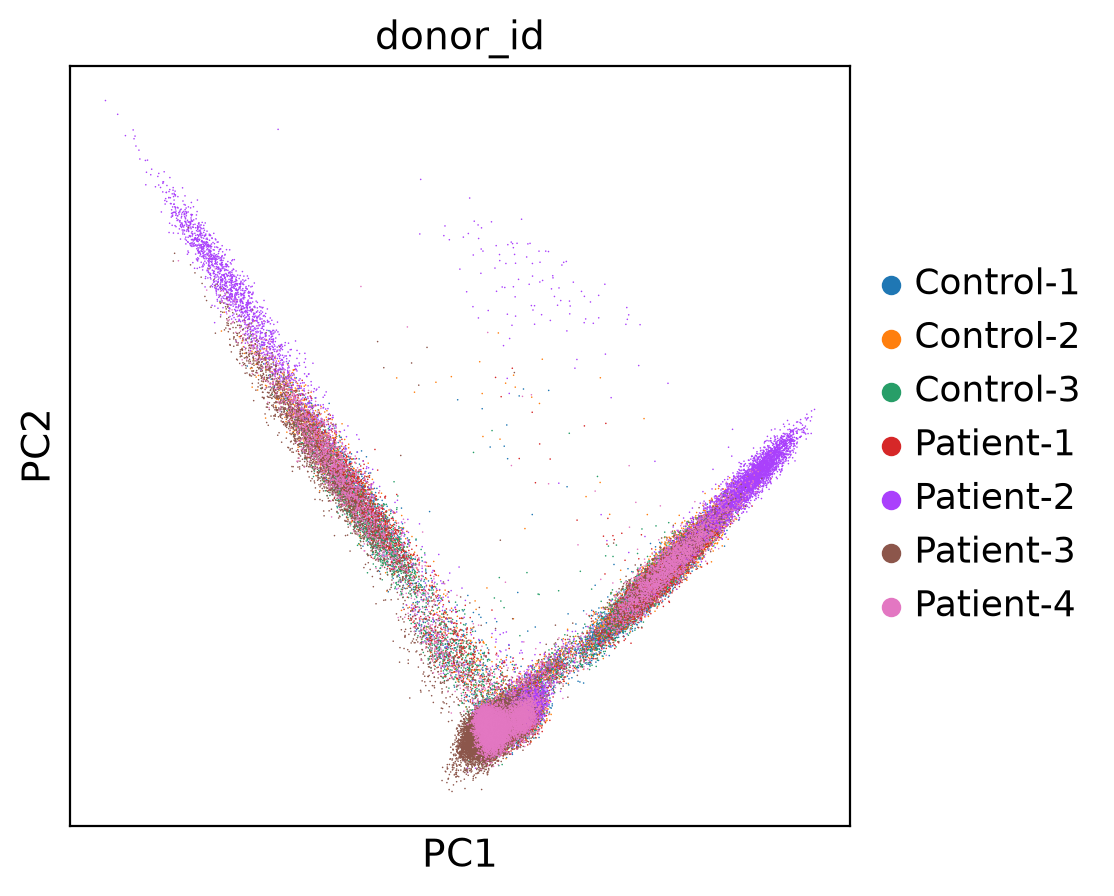

In [34]:
sc.pl.pca(adata, color = 'donor_id')

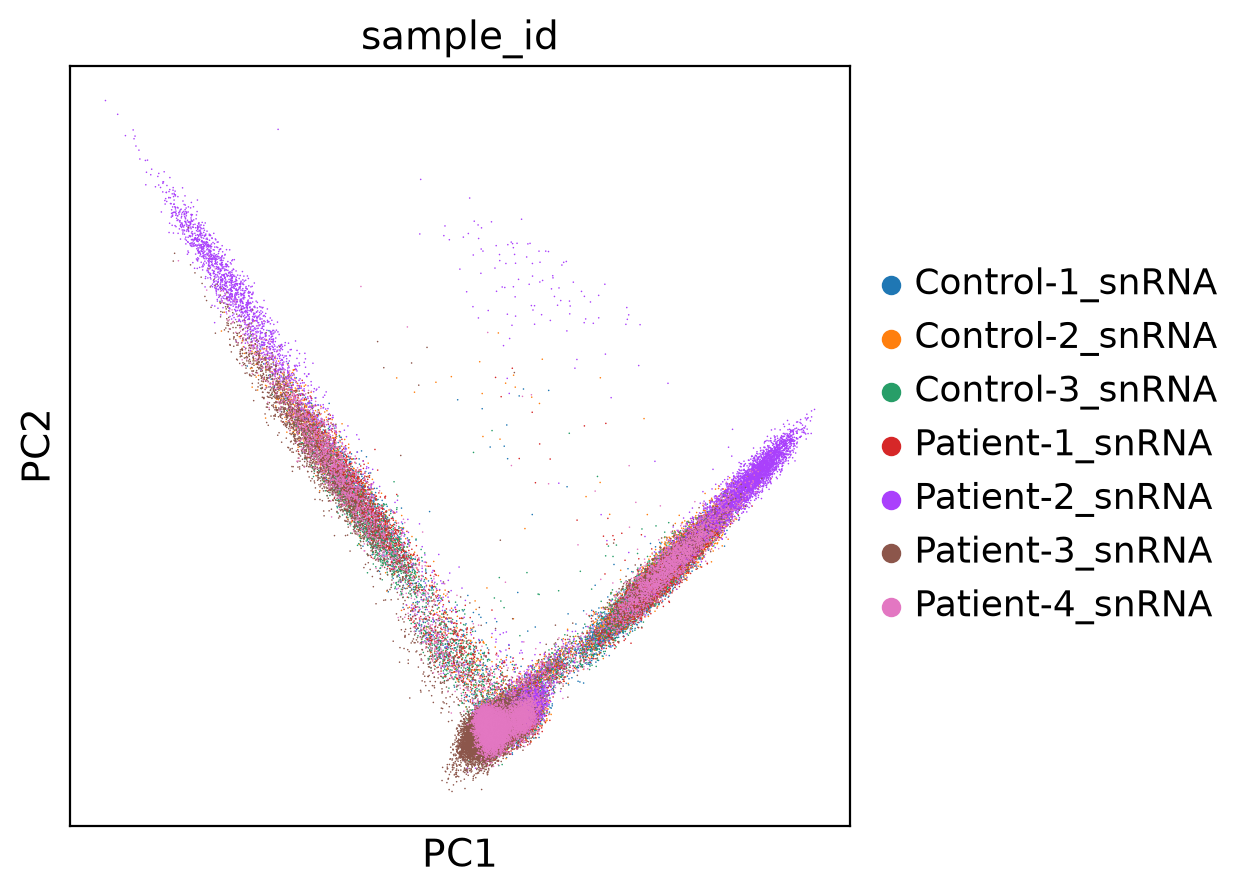

In [35]:
sc.pl.pca(adata, color = 'sample_id')

computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:30)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:50)


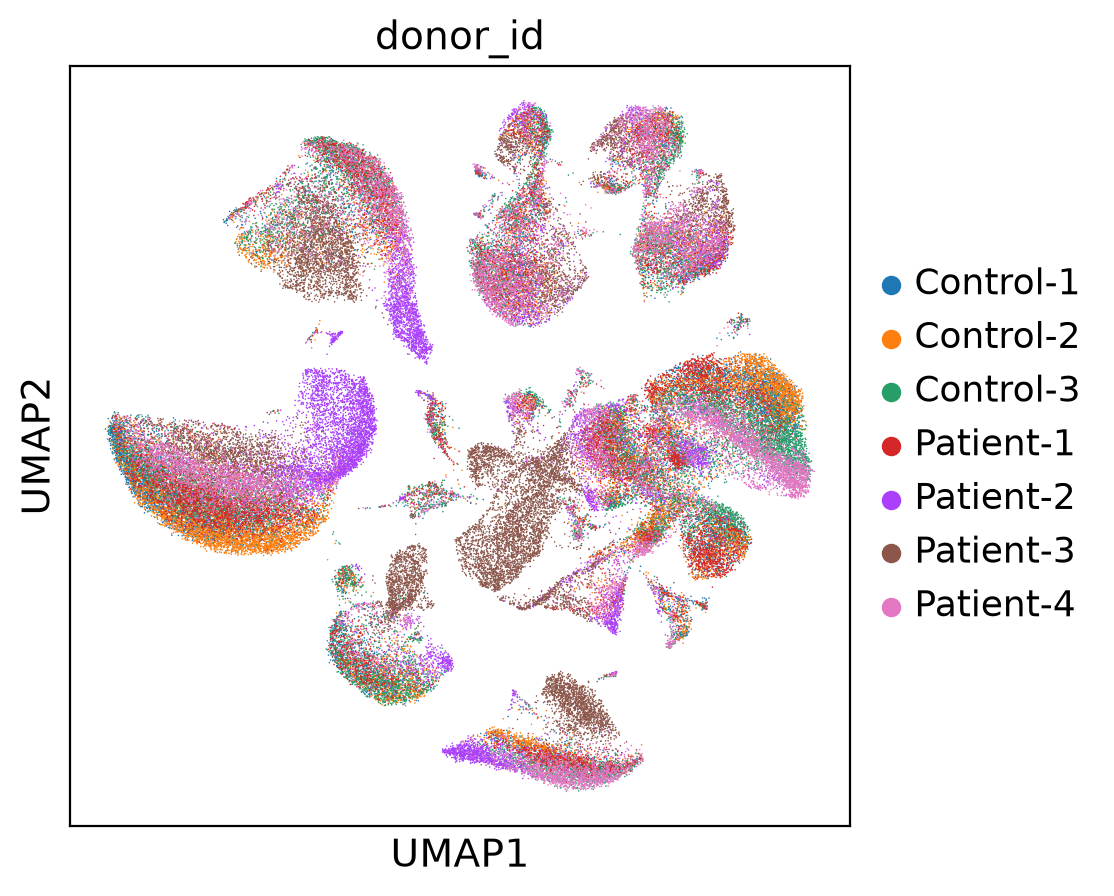

In [36]:
# without batch correction

sc.pp.neighbors(adata, use_rep = 'X_pca', n_pcs = 20)
sc.tl.umap(adata)
sc.pl.umap(adata, color = 'donor_id', save=f"_{TODAY}_{dataset}_donor_xharmony_npcs=20.png")

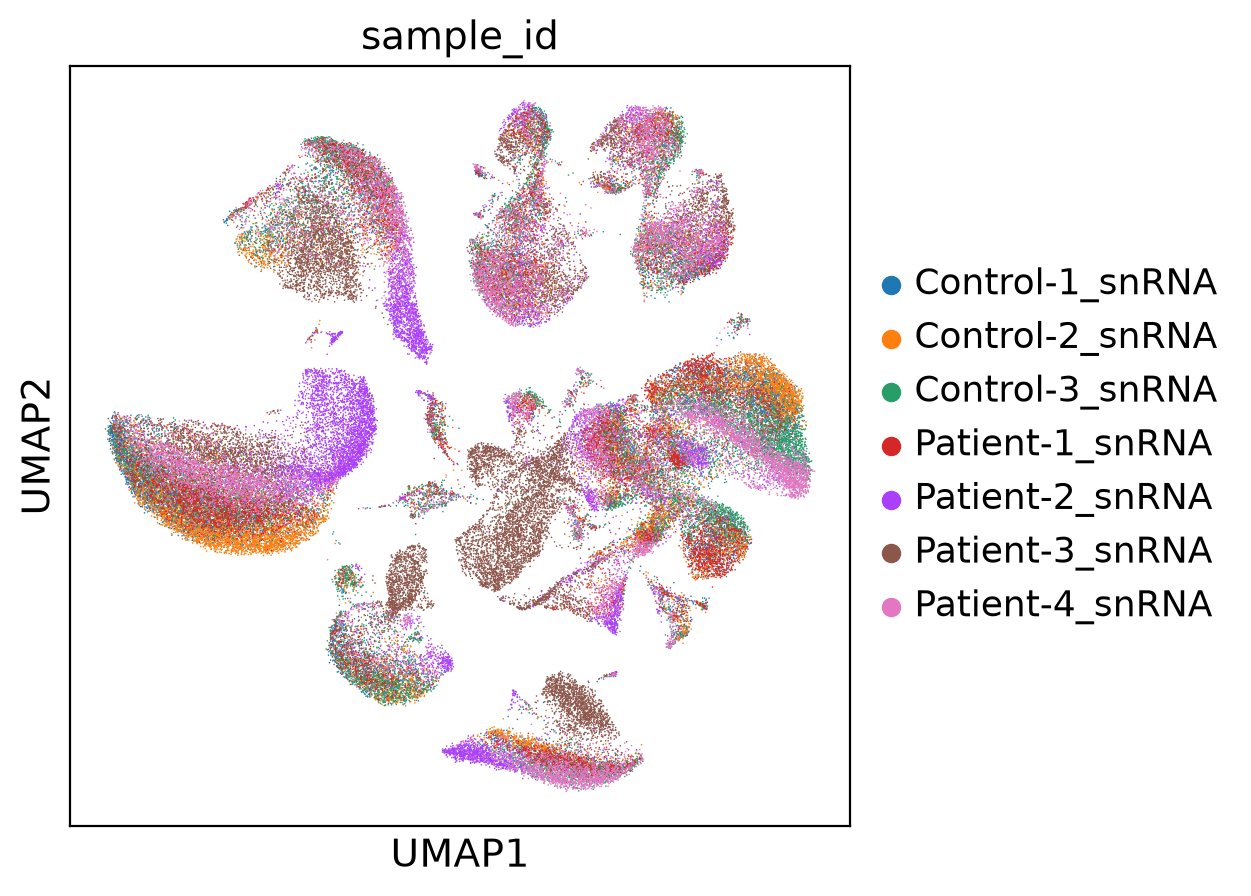

In [37]:
sc.pl.umap(adata, color = 'sample_id', save=f"_{TODAY}_{dataset}_sample_xharmony_npcs=20.png")

In [38]:
import harmonypy as hm

ho = hm.run_harmony(
    adata.obsm["X_pca"].astype(np.float64),
    adata.obs,
    "sample_id",
    max_iter_harmony=50
)

print(ho.Z_corr.shape)
adata.obsm["X_pca_harmony"] = np.asarray(ho.Z_corr)

2026-09-13 00:54:24,084 - harmonypy - INFO - Running Harmony
2026-09-13 00:54:24,086 - harmonypy - INFO -   Parameters:
2026-09-13 00:54:24,087 - harmonypy - INFO -     max_iter_harmony: 50
2026-09-13 00:54:24,088 - harmonypy - INFO -     max_iter_kmeans: 4
2026-09-13 00:54:24,089 - harmonypy - INFO -     epsilon_cluster: 0.001
2026-09-13 00:54:24,090 - harmonypy - INFO -     epsilon_harmony: 0.01
2026-09-13 00:54:24,091 - harmonypy - INFO -     nclust: 100
2026-09-13 00:54:24,092 - harmonypy - INFO -     block_size: 0.05
2026-09-13 00:54:24,092 - harmonypy - INFO -     lamb: dynamic (alpha=0.2)
2026-09-13 00:54:24,094 - harmonypy - INFO -     theta: [2. 2. 2. 2. 2. 2. 2.]
2026-09-13 00:54:24,095 - harmonypy - INFO -     sigma: [0.1 0.1 0.1 0.1 0.1]...
2026-09-13 00:54:24,096 - harmonypy - INFO -     verbose: True
2026-09-13 00:54:24,097 - harmonypy - INFO -     random_state: 0
2026-09-13 00:54:24,097 - harmonypy - INFO -   Data: 50 PCs × 93922 cells
2026-09-13 00:54:24,098 - harmonypy

(93922, 50)


computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:05)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:50)


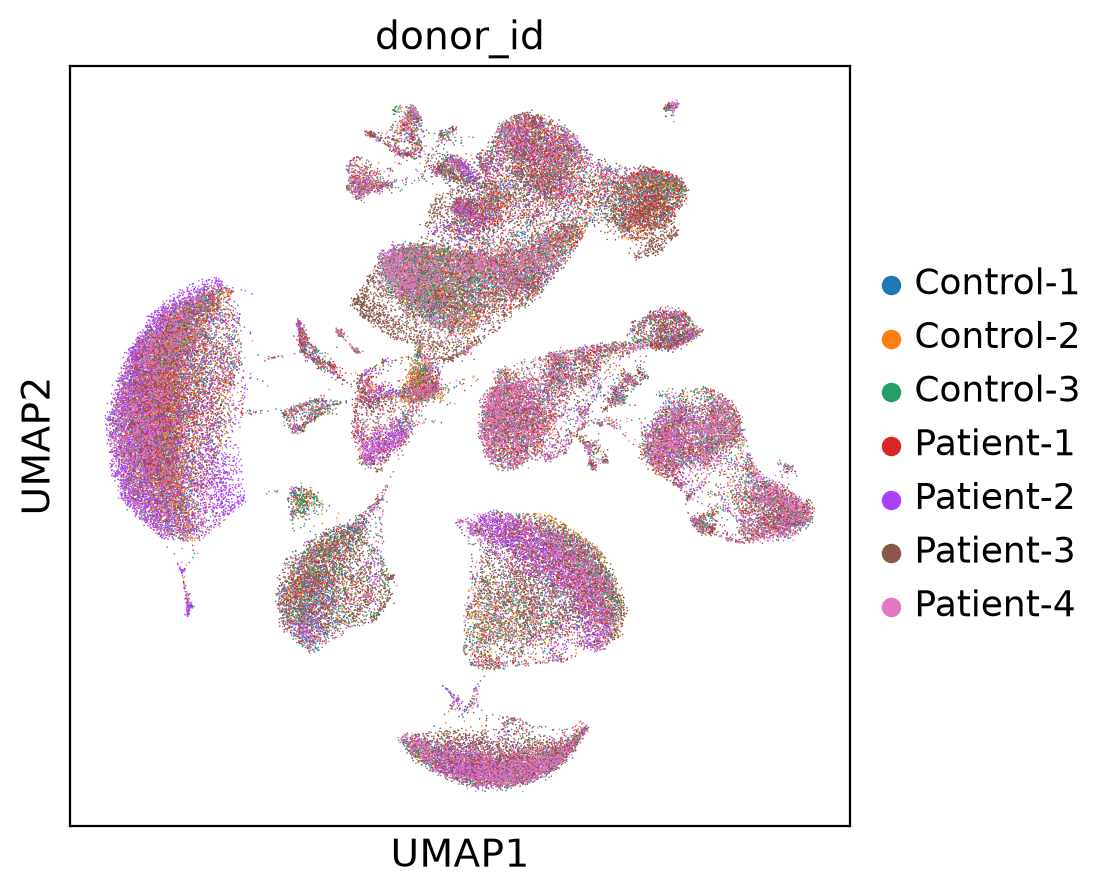

In [39]:
# with batch correction

sc.pp.neighbors(adata, use_rep = 'X_pca_harmony', n_pcs = 20)
sc.tl.umap(adata)
sc.pl.umap(adata, color = 'donor_id', save=f"_{TODAY}_{dataset}_donor_harmony_npcs=20.png")

In [ ]:
sc.pl.umap(adata, color = 'sample_id', save=f"_{TODAY}_{dataset}_sample_harmony_npcs=20.png")

# 4. Clustering

In [ ]:
sc.tl.leiden(adata, resolution = 0.5, key_added='leiden_05')
sc.tl.leiden(adata, resolution = 1.0, key_added='leiden_10')

running Leiden clustering


/tmp/ipykernel_3419353/4008177221.py:1: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, resolution = 0.5, key_added='leiden_05')


In [ ]:
scl.us(adata, 'leiden_05,leiden_10')

In [ ]:
sc.tl.rank_genes_groups(adata, groupby='leiden_05', method='wilcoxon', use_raw=False)

In [ ]:
adata.var_names = adata.var['gene_symbols'].copy()
adata.var_names_make_unique()

print(adata.var_names[:10])
print(adata.var_names.is_unique)

In [ ]:
sc.pl.rank_genes_groups(adata, ncols = 6)

In [ ]:
raw = adata.raw.to_adata()

raw.var_names = raw.var['gene_symbols'].astype(str)
raw.var_names_make_unique()

adata.raw = raw

In [ ]:
adata.raw.var.index.name = "feature_id"
adata.var.index.name = "feature_id"

if adata.raw is not None:
    adata.raw.var.index.name = "feature_id"

In [ ]:
gene_to_id = dict(zip(odata.var["gene_symbols"], odata.var_names))

adata.var["source_gene_id"] = adata.var["gene_symbols"].map(gene_to_id)

print(adata.var[["gene_symbols", "source_gene_id"]].head())
print("Unmapped:", adata.var["source_gene_id"].isna().sum())

In [ ]:
M = scl.markers.marker(adata,'leiden_05')
M.plot_marker()

In [ ]:
adata.write(f"/data/SJLEE/Epilepsy_Microglia/notebooks/epilepsy_microglia/data/processed/{dataset}/{dataset}_qc.h5ad")

# 5. Lv.1 Annotation

In [ ]:
markers_full = {
    "Microglia": [
        "P2RY12", "P2RY13", "TMEM119", "CX3CR1",
        "C1QA", "C1QB", "C1QC", "GPR34", "CSF1R"
    ],
    "Macrophage_MDM": [
        "FCGR3A", "LILRB1", "LILRB2", "CTSD",
        "CTSB", "LGALS3", "APOE", "SPP1"
    ],
    "Lymphocyte": [
        "CD3D", "CD3E", "TRBC1", "TRBC2",
        "SKAP1", "CD96", "CCL4", "NKG7"
    ],
    "Astrocyte": [
        "AQP4", "SLC1A2", "SLC1A3", "GFAP", "ALDH1L1"
    ],
    "Oligodendrocyte": [
        "PLP1", "MBP", "MOG", "MAG", "MOBP"
    ],
    "OPC": [
        "PDGFRA", "CSPG4", "VCAN", "OLIG1", "OLIG2"
    ],
    "Endothelial": [
        "CLDN5", "FLT1", "PECAM1", "VWF", "EMCN"
    ],
    "Pericyte": [
        "RGS5", "ABCC9", "PDGFRB", "CSPG4", "MCAM"
    ],
}

gene_set = set(adata.var["gene_symbols"].dropna())

markers = {
    celltype: [gene for gene in genes if gene in gene_set]
    for celltype, genes in markers_full.items()
}

In [ ]:
umap_markers = [
    # Microglia
    "P2RY12", "TMEM119", "C1QA",

    # Macrophage / MDM
    "FCGR3A", "LGALS3", "SPP1",

    # Lymphocyte
    "CD3D", "NKG7",

    # Astrocyte
    "AQP4", "SLC1A2",

    # Oligodendrocyte
    "PLP1", "MOBP",

    # OPC
    "PDGFRA", "VCAN",

    # Endothelial
    "CLDN5", "VWF",

    # Pericyte
    "RGS5", "PDGFRB",
]

In [ ]:
sc.pl.dotplot(
    adata,
    markers,
    groupby="leiden_05",
    standard_scale="var",
    dendrogram=False,
    figsize=(max(12, len(markers) * 0.35), 6),
)

In [ ]:
scl.us(adata, umap_markers)

In [ ]:
lv1_map = {
    "0": "Microglia",
    "1": "Microglia",
    "2": "Microglia",
    "3": "Microglia",
    "4": "Microglia",
    "5": "Lymphocyte",
    "6": "Macrophage/MDM",
    "7": "Pericyte/Endothelial",
    "8": "Pericyte/Endothelial",
    "9": "Macrophage/MDM",
    "10": "Oligodendrocyte",
    "11": "Ribosomal",
    "12": "Lymphocyte",
    "13": "lowquality",
}

adata.obs["celltype_lv1"] = (
    adata.obs["leiden_05"]
    .astype(str)
    .map(lv1_map)
    .astype("category")
)

In [ ]:
scl.us(adata, 'leiden_05,celltype_lv1')

In [ ]:
odata = sc.read_h5ad("/data/SJLEE/Epilepsy_Microglia/notebooks/epilepsy_microglia/data/processed/kumar/kumar.h5ad")
odata.var

In [ ]:
adata.write(f"/data/SJLEE/Epilepsy_Microglia/notebooks/epilepsy_microglia/data/processed/{dataset}/{dataset}_qc.h5ad")

# 6. Microglia Lv. 2 annotation

In [ ]:
print(adata)

mdata = adata[
    adata.obs["celltype_lv1"].isin(["Microglia", "Macrophage/MDM"])
].copy()

In [ ]:
mdata

In [ ]:
mdata.X = mdata.layers['counts'].copy()
print(mdata.X.max(), mdata.X.min())

In [ ]:
# preprocess
sc.pp.normalize_total(mdata)
sc.pp.log1p(mdata)
sc.pp.highly_variable_genes(mdata)
sc.pp.scale(mdata)

In [ ]:
# feature selection
sc.tl.pca(mdata)
sc.pl.pca_variance_ratio(mdata)

In [ ]:
sc.pp.neighbors(mdata, use_rep = 'X_pca', n_pcs=20)
sc.tl.umap(mdata)
scl.us(mdata, 'donor_id,sample_id')

In [ ]:
#mdata.obs.drop(columns=["leiden_05", "leiden_10"], inplace=True)
#mdata.uns.pop("cdm_leiden_05", None)
for key in ["leiden_05", "leiden_10", "leiden_05_colors", "leiden_10_colors"]:
    mdata.uns.pop(key, None)

In [ ]:
mdata

In [ ]:
adata.write(f"/data/SJLEE/Epilepsy_Microglia/notebooks/epilepsy_microglia/data/processed/{dataset}/{dataset}_mg.h5ad")